In [1]:
# ============================================================
# NOTEBOOK 09 — CELL 1
# CXR DATA AUGMENTATION
# ENVIRONMENT + FROZEN DATA VALIDATION
# ============================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch
import torchvision
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt


print("=" * 80)
print("NOTEBOOK 09 — CELL 1")
print("CXR DATA AUGMENTATION")
print("ENVIRONMENT + FROZEN DATA VALIDATION")
print("=" * 80)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# ============================================================
# 2. ENVIRONMENT
# ============================================================

print()
print("=" * 80)
print("ENVIRONMENT")
print("=" * 80)

print("Python / PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "CUDA device:",
        torch.cuda.get_device_name(0)
    )
else:
    print("Execution device: CPU")


# ============================================================
# 3. PATHS
# ============================================================

BASE_DIR = Path(
    r"C:\TBP\Metadata"
)

CXR_PREPARATION_DIR = (
    BASE_DIR
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_DIR = (
    CXR_PREPARATION_DIR
    / "Final_2058_CXR_Modeling"
)

QC_DIR = (
    CXR_PREPARATION_DIR
    / "QC"
)

SPLIT_DIR = (
    QC_DIR
    / "Master_Condition_Level_Split"
)

FINAL_METADATA_PATH = (
    QC_DIR
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

MASTER_SPLIT_PATH = (
    SPLIT_DIR
    / "TB_Portals_March2025_Notebook08_Master_Condition_Level_Split.csv"
)


AUGMENTATION_QC_DIR = (
    QC_DIR
    / "CXR_Data_Augmentation_QC"
)

AUGMENTATION_QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 4. PATH VALIDATION
# ============================================================

print()
print("=" * 80)
print("PATH VALIDATION")
print("=" * 80)

print(
    "Final CXR directory:",
    "FOUND" if FINAL_CXR_DIR.exists() else "MISSING"
)

print(
    "Final metadata:",
    "FOUND" if FINAL_METADATA_PATH.exists() else "MISSING"
)

print(
    "Master split:",
    "FOUND" if MASTER_SPLIT_PATH.exists() else "MISSING"
)


if not FINAL_CXR_DIR.exists():
    raise FileNotFoundError(
        f"Missing CXR directory:\n{FINAL_CXR_DIR}"
    )

if not FINAL_METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing final metadata:\n{FINAL_METADATA_PATH}"
    )

if not MASTER_SPLIT_PATH.exists():
    raise FileNotFoundError(
        f"Missing master split:\n{MASTER_SPLIT_PATH}"
    )


print(
    "Path validation: PASS"
)


# ============================================================
# 5. LOAD FINAL METADATA
# ============================================================

metadata = pd.read_csv(
    FINAL_METADATA_PATH
)

master_split = pd.read_csv(
    MASTER_SPLIT_PATH
)


print()
print("=" * 80)
print("FROZEN DATA")
print("=" * 80)

print(
    "Final metadata records:",
    len(metadata)
)

print(
    "Master split records:",
    len(master_split)
)


# ============================================================
# 6. REQUIRED SCHEMA
# ============================================================

required_metadata_columns = [
    "stem",
    "condition_id",
    "target_class",
    "target_binary",
    "source_type"
]

required_split_columns = [
    "condition_id",
    "split"
]


missing_metadata_columns = [
    column
    for column in required_metadata_columns
    if column not in metadata.columns
]

missing_split_columns = [
    column
    for column in required_split_columns
    if column not in master_split.columns
]


if missing_metadata_columns:
    raise RuntimeError(
        "Missing metadata columns: "
        + str(missing_metadata_columns)
    )

if missing_split_columns:
    raise RuntimeError(
        "Missing split columns: "
        + str(missing_split_columns)
    )


print(
    "Metadata schema: PASS"
)

print(
    "Master split schema: PASS"
)


# ============================================================
# 7. MERGE FROZEN SPLIT
# ============================================================

metadata = metadata.drop(
    columns=[
        "split"
    ],
    errors="ignore"
)


split_mapping = (
    master_split[
        [
            "condition_id",
            "split"
        ]
    ]
    .copy()
)


if split_mapping["condition_id"].duplicated().any():

    raise RuntimeError(
        "Duplicate condition IDs in master split."
    )


metadata_with_split = metadata.merge(
    split_mapping,
    on="condition_id",
    how="left",
    validate="one_to_one"
)


if metadata_with_split["split"].isna().any():

    raise RuntimeError(
        "Some final metadata records are missing "
        "from the frozen master split."
    )


print(
    "Frozen split merge: PASS"
)


# ============================================================
# 8. FROZEN COHORT VALIDATION
# ============================================================

expected_total = 2058
expected_train = 1234
expected_validation = 412
expected_test = 412


if len(metadata_with_split) != expected_total:

    raise RuntimeError(
        "Unexpected final cohort size."
    )


split_counts = (
    metadata_with_split[
        "split"
    ]
    .value_counts()
    .sort_index()
)


print()
print("=" * 80)
print("FROZEN SPLIT")
print("=" * 80)

print(
    split_counts
)


expected_counts = {
    "train": expected_train,
    "validation": expected_validation,
    "test": expected_test
}


for split_name, expected_count in expected_counts.items():

    actual_count = int(
        split_counts.get(
            split_name,
            0
        )
    )

    if actual_count != expected_count:

        raise RuntimeError(
            f"{split_name} count mismatch: "
            f"expected {expected_count}, "
            f"found {actual_count}"
        )


print(
    "Frozen split counts: PASS"
)


# ============================================================
# 9. TARGET VALIDATION
# ============================================================

target_counts = (
    metadata_with_split[
        "target_class"
    ]
    .value_counts()
)


print()
print("=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

print(
    target_counts
)


if int(
    target_counts.get(
        "DR-TB",
        0
    )
) != 1339:

    raise RuntimeError(
        "Unexpected DR-TB count."
    )


if int(
    target_counts.get(
        "DS-TB",
        0
    )
) != 719:

    raise RuntimeError(
        "Unexpected DS-TB count."
    )


target_mapping_errors = (
    (
        (
            metadata_with_split["target_class"]
            == "DR-TB"
        )
        &
        (
            metadata_with_split["target_binary"]
            != 1
        )
    )
    |
    (
        (
            metadata_with_split["target_class"]
            == "DS-TB"
        )
        &
        (
            metadata_with_split["target_binary"]
            != 0
        )
    )
)


if target_mapping_errors.any():

    raise RuntimeError(
        "Target class/binary mapping mismatch."
    )


print(
    "Target validation: PASS"
)


# ============================================================
# 10. SOURCE IMAGE VALIDATION
# ============================================================

expected_stems = set(
    metadata_with_split[
        "stem"
    ]
)

actual_stems = {
    path.stem
    for path in FINAL_CXR_DIR.glob("*.png")
}


missing_stems = (
    expected_stems
    -
    actual_stems
)

unexpected_stems = (
    actual_stems
    -
    expected_stems
)


print()
print("=" * 80)
print("SOURCE IMAGE VALIDATION")
print("=" * 80)

print(
    "Expected images:",
    len(expected_stems)
)

print(
    "Found images:",
    len(actual_stems)
)

print(
    "Missing:",
    len(missing_stems)
)

print(
    "Unexpected:",
    len(unexpected_stems)
)


if missing_stems:

    raise RuntimeError(
        "Expected CXR images are missing."
    )

if unexpected_stems:

    raise RuntimeError(
        "Unexpected CXR images found."
    )


print(
    "Source image validation: PASS"
)


# ============================================================
# 11. SOURCE IMAGE INTEGRITY
# ============================================================

sample_stems = list(
    sorted(
        expected_stems
    )
)[:20]


invalid_images = []


for stem in sample_stems:

    image_path = (
        FINAL_CXR_DIR
        / f"{stem}.png"
    )

    try:

        with Image.open(
            image_path
        ) as image:

            image.verify()

    except Exception as error:

        invalid_images.append(
            (
                stem,
                str(error)
            )
        )


print()
print("=" * 80)
print("SOURCE IMAGE SAMPLE INTEGRITY")
print("=" * 80)

print(
    "Images checked:",
    len(sample_stems)
)

print(
    "Invalid:",
    len(invalid_images)
)


if invalid_images:

    raise RuntimeError(
        "Invalid source images detected:\n"
        + str(invalid_images)
    )


print(
    "Source image sample integrity: PASS"
)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 09 — CELL 1 FINAL STATUS")
print("=" * 80)

print()

print(
    "Frozen CXR cohort:",
    len(metadata_with_split)
)

print(
    "Train:",
    expected_train
)

print(
    "Validation:",
    expected_validation
)

print(
    "Test:",
    expected_test
)

print(
    "DR-TB:",
    int(target_counts["DR-TB"])
)

print(
    "DS-TB:",
    int(target_counts["DS-TB"])
)

print()

print(
    "Augmentation notebook initialization: PASS"
)

print("=" * 80)

NOTEBOOK 09 — CELL 1
CXR DATA AUGMENTATION
ENVIRONMENT + FROZEN DATA VALIDATION

ENVIRONMENT
Python / PyTorch: 2.13.0+cpu
Torchvision: 0.28.0+cpu
CUDA available: False
Execution device: CPU

PATH VALIDATION
Final CXR directory: FOUND
Final metadata: FOUND
Master split: FOUND
Path validation: PASS

FROZEN DATA
Final metadata records: 2058
Master split records: 2058
Metadata schema: PASS
Master split schema: PASS
Frozen split merge: PASS

FROZEN SPLIT
split
test           412
train         1234
validation     412
Name: count, dtype: int64
Frozen split counts: PASS

TARGET DISTRIBUTION
target_class
DR-TB    1339
DS-TB     719
Name: count, dtype: int64
Target validation: PASS

SOURCE IMAGE VALIDATION
Expected images: 2058
Found images: 2058
Missing: 0
Unexpected: 0
Source image validation: PASS

SOURCE IMAGE SAMPLE INTEGRITY
Images checked: 20
Invalid: 0
Source image sample integrity: PASS

NOTEBOOK 09 — CELL 1 FINAL STATUS

Frozen CXR cohort: 2058
Train: 1234
Validation: 412
Test: 412
DR-

In [3]:
# ============================================================
# NOTEBOOK 09 — CELL 2
# CONTROLLED CXR AUGMENTATION
# DEFINITION + CONFIGURATION QC
# ============================================================

import json
import pandas as pd
import torch
import torchvision.transforms as transforms


print("=" * 80)
print("NOTEBOOK 09 — CELL 2")
print("CONTROLLED CXR AUGMENTATION")
print("DEFINITION + CONFIGURATION QC")
print("=" * 80)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

RANDOM_SEED = 42

torch.manual_seed(
    RANDOM_SEED
)


# ============================================================
# 2. FINAL AUGMENTATION CONFIGURATION
# ============================================================

AUGMENTATION_CONFIG = {

    "random_affine": {

        "enabled": True,

        "degrees": 5.0,

        "translate_x": 0.05,

        "translate_y": 0.05,

        "scale_min": 0.95,

        "scale_max": 1.05,

        "interpolation": "bilinear",

        "fill": 0
    },

    "color_jitter": {

        "enabled": True,

        "brightness": 0.08,

        "contrast": 0.08

    },

    "horizontal_flip": False,

    "vertical_flip": False,

    "large_rotation": False,

    "elastic_deformation": False,

    "aggressive_crop": False,

    "cutmix": False,

    "mixup": False,

    "random_erasing": False,

    "apply_to": "training_only",

    "validation_augmentation": False,

    "test_augmentation": False,

    "on_the_fly": True,

    "save_augmented_images": False
}


# ============================================================
# 3. CREATE ACTUAL TORCHVISION AUGMENTATION
# ============================================================

train_augmentation = transforms.Compose([

    transforms.RandomAffine(

        degrees=AUGMENTATION_CONFIG[
            "random_affine"
        ][
            "degrees"
        ],

        translate=(

            AUGMENTATION_CONFIG[
                "random_affine"
            ][
                "translate_x"
            ],

            AUGMENTATION_CONFIG[
                "random_affine"
            ][
                "translate_y"
            ]
        ),

        scale=(

            AUGMENTATION_CONFIG[
                "random_affine"
            ][
                "scale_min"
            ],

            AUGMENTATION_CONFIG[
                "random_affine"
            ][
                "scale_max"
            ]
        ),

        interpolation=(
            transforms.InterpolationMode.BILINEAR
        ),

        fill=AUGMENTATION_CONFIG[
            "random_affine"
        ][
            "fill"
        ]
    ),

    # IMPORTANT:
    # Only brightness and contrast are specified.
    # Saturation and hue are intentionally omitted.
    transforms.ColorJitter(

        brightness=AUGMENTATION_CONFIG[
            "color_jitter"
        ][
            "brightness"
        ],

        contrast=AUGMENTATION_CONFIG[
            "color_jitter"
        ][
            "contrast"
        ]
    )
])


# ============================================================
# 4. PRINT CONFIGURATION
# ============================================================

print()
print("=" * 80)
print("FINAL TRAINING AUGMENTATION")
print("=" * 80)

print(
    train_augmentation
)


print()
print("RandomAffine:")
print("  Rotation: ±5 degrees")
print("  Translation X: ±5%")
print("  Translation Y: ±5%")
print("  Scale: 0.95–1.05")
print("  Interpolation: bilinear")
print("  Fill: 0")


print()
print("ColorJitter:")
print("  Brightness: ±8%")
print("  Contrast: ±8%")
print("  Saturation: OFF")
print("  Hue: OFF")


print()
print("Disabled augmentations:")
print("  Horizontal flip: OFF")
print("  Vertical flip: OFF")
print("  Large rotation: OFF")
print("  Elastic deformation: OFF")
print("  Aggressive crop: OFF")
print("  CutMix: OFF")
print("  MixUp: OFF")
print("  Random erasing: OFF")


# ============================================================
# 5. PARAMETER VALIDATION
# ============================================================

affine_config = (
    AUGMENTATION_CONFIG[
        "random_affine"
    ]
)

color_config = (
    AUGMENTATION_CONFIG[
        "color_jitter"
    ]
)


# ------------------------------------------------------------
# Rotation
# ------------------------------------------------------------

if affine_config[
    "degrees"
] != 5.0:

    raise RuntimeError(
        "Unexpected rotation parameter."
    )


# ------------------------------------------------------------
# Translation
# ------------------------------------------------------------

if not (

    affine_config[
        "translate_x"
    ] == 0.05

    and

    affine_config[
        "translate_y"
    ] == 0.05

):

    raise RuntimeError(
        "Unexpected translation parameters."
    )


# ------------------------------------------------------------
# Scale
# ------------------------------------------------------------

if not (

    affine_config[
        "scale_min"
    ] == 0.95

    and

    affine_config[
        "scale_max"
    ] == 1.05

):

    raise RuntimeError(
        "Unexpected scale parameters."
    )


# ------------------------------------------------------------
# Brightness
# ------------------------------------------------------------

if color_config[
    "brightness"
] != 0.08:

    raise RuntimeError(
        "Unexpected brightness parameter."
    )


# ------------------------------------------------------------
# Contrast
# ------------------------------------------------------------

if color_config[
    "contrast"
] != 0.08:

    raise RuntimeError(
        "Unexpected contrast parameter."
    )


# ------------------------------------------------------------
# Disabled transformations
# ------------------------------------------------------------

disabled_parameters = [

    AUGMENTATION_CONFIG[
        "horizontal_flip"
    ],

    AUGMENTATION_CONFIG[
        "vertical_flip"
    ],

    AUGMENTATION_CONFIG[
        "large_rotation"
    ],

    AUGMENTATION_CONFIG[
        "elastic_deformation"
    ],

    AUGMENTATION_CONFIG[
        "aggressive_crop"
    ],

    AUGMENTATION_CONFIG[
        "cutmix"
    ],

    AUGMENTATION_CONFIG[
        "mixup"
    ],

    AUGMENTATION_CONFIG[
        "random_erasing"
    ]
]


if any(
    disabled_parameters
):

    raise RuntimeError(
        "A disabled augmentation was accidentally enabled."
    )


# ------------------------------------------------------------
# Training-only validation
# ------------------------------------------------------------

if AUGMENTATION_CONFIG[
    "apply_to"
] != "training_only":

    raise RuntimeError(
        "Augmentation must be training-only."
    )


if AUGMENTATION_CONFIG[
    "validation_augmentation"
]:

    raise RuntimeError(
        "Validation augmentation must remain OFF."
    )


if AUGMENTATION_CONFIG[
    "test_augmentation"
]:

    raise RuntimeError(
        "Test augmentation must remain OFF."
    )


# ------------------------------------------------------------
# On-the-fly validation
# ------------------------------------------------------------

if not AUGMENTATION_CONFIG[
    "on_the_fly"
]:

    raise RuntimeError(
        "Augmentation must be applied on-the-fly."
    )


if AUGMENTATION_CONFIG[
    "save_augmented_images"
]:

    raise RuntimeError(
        "Augmented images must not be physically saved."
    )


print()
print(
    "Augmentation parameter validation: PASS"
)


# ============================================================
# 6. TRANSFORM COMPONENT VALIDATION
# ============================================================

transform_types = [

    type(transform).__name__

    for transform
    in train_augmentation.transforms
]


print()
print("=" * 80)
print("TRANSFORM COMPONENTS")
print("=" * 80)

print(
    "Transform sequence:",
    transform_types
)


expected_transform_types = [
    "RandomAffine",
    "ColorJitter"
]


if transform_types != expected_transform_types:

    raise RuntimeError(
        "Unexpected augmentation transform sequence."
    )


print(
    "Transform component validation: PASS"
)


# ============================================================
# 7. SAVE FROZEN AUGMENTATION CONFIGURATION
# ============================================================

config_rows = [

    {
        "parameter":
            "rotation_degrees",

        "value":
            "±5",

        "enabled":
            True
    },

    {
        "parameter":
            "translation",

        "value":
            "±5%",

        "enabled":
            True
    },

    {
        "parameter":
            "scale",

        "value":
            "0.95–1.05",

        "enabled":
            True
    },

    {
        "parameter":
            "brightness",

        "value":
            "±8%",

        "enabled":
            True
    },

    {
        "parameter":
            "contrast",

        "value":
            "±8%",

        "enabled":
            True
    },

    {
        "parameter":
            "saturation",

        "value":
            "OFF",

        "enabled":
            False
    },

    {
        "parameter":
            "hue",

        "value":
            "OFF",

        "enabled":
            False
    },

    {
        "parameter":
            "horizontal_flip",

        "value":
            "OFF",

        "enabled":
            False
    },

    {
        "parameter":
            "vertical_flip",

        "value":
            "OFF",

        "enabled":
            False
    },

    {
        "parameter":
            "large_rotation",

        "value":
            "OFF",

        "enabled":
            False
    },

    {
        "parameter":
            "elastic_deformation",

        "value":
            "OFF",

        "enabled":
            False
    },

    {
        "parameter":
            "aggressive_crop",

        "value":
            "OFF",

        "enabled":
            False
    },

    {
        "parameter":
            "cutmix",

        "value":
            "OFF",

        "enabled":
            False
    },

    {
        "parameter":
            "mixup",

        "value":
            "OFF",

        "enabled":
            False
    },

    {
        "parameter":
            "random_erasing",

        "value":
            "OFF",

        "enabled":
            False
    },

    {
        "parameter":
            "application",

        "value":
            "training_only",

        "enabled":
            True
    },

    {
        "parameter":
            "execution",

        "value":
            "on_the_fly",

        "enabled":
            True
    },

    {
        "parameter":
            "save_augmented_images",

        "value":
            "False",

        "enabled":
            False
    }
]


augmentation_config_df = pd.DataFrame(
    config_rows
)


AUGMENTATION_CONFIG_PATH = (
    AUGMENTATION_QC_DIR
    /
    "TB_Portals_March2025_Notebook09_Final_Augmentation_Configuration.csv"
)


augmentation_config_df.to_csv(
    AUGMENTATION_CONFIG_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 8. SAVE JSON CONFIGURATION
# ============================================================

AUGMENTATION_JSON_PATH = (
    AUGMENTATION_QC_DIR
    /
    "TB_Portals_March2025_Notebook09_Final_Augmentation_Configuration.json"
)


with open(
    AUGMENTATION_JSON_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        AUGMENTATION_CONFIG,
        file,
        indent=4
    )


print()
print(
    "Configuration CSV saved:"
)

print(
    AUGMENTATION_CONFIG_PATH
)

print()
print(
    "Configuration JSON saved:"
)

print(
    AUGMENTATION_JSON_PATH
)


# ============================================================
# 9. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 09 — CELL 2 FINAL STATUS")
print("=" * 80)

print()

print(
    "Training augmentation: ON"
)

print(
    "Validation augmentation: OFF"
)

print(
    "Test augmentation: OFF"
)

print(
    "On-the-fly augmentation: YES"
)

print(
    "Physical augmented files: NO"
)

print(
    "RandomAffine + ColorJitter: PASS"
)

print(
    "Brightness/contrast only: PASS"
)

print(
    "Saturation: OFF"
)

print(
    "Hue: OFF"
)

print(
    "Disabled transformations: PASS"
)

print(
    "Configuration saved: PASS"
)

print()
print("=" * 80)
print(
    "CELL 2 — AUGMENTATION CONFIGURATION QC: PASS"
)
print("=" * 80)

NOTEBOOK 09 — CELL 2
CONTROLLED CXR AUGMENTATION
DEFINITION + CONFIGURATION QC

FINAL TRAINING AUGMENTATION
Compose(
    RandomAffine(degrees=[-5.0, 5.0], translate=(0.05, 0.05), scale=(0.95, 1.05), interpolation=bilinear)
    ColorJitter(brightness=(0.92, 1.08), contrast=(0.92, 1.08), saturation=None, hue=None)
)

RandomAffine:
  Rotation: ±5 degrees
  Translation X: ±5%
  Translation Y: ±5%
  Scale: 0.95–1.05
  Interpolation: bilinear
  Fill: 0

ColorJitter:
  Brightness: ±8%
  Contrast: ±8%
  Saturation: OFF
  Hue: OFF

Disabled augmentations:
  Horizontal flip: OFF
  Vertical flip: OFF
  Large rotation: OFF
  Elastic deformation: OFF
  Aggressive crop: OFF
  CutMix: OFF
  MixUp: OFF
  Random erasing: OFF

Augmentation parameter validation: PASS

TRANSFORM COMPONENTS
Transform sequence: ['RandomAffine', 'ColorJitter']
Transform component validation: PASS

Configuration CSV saved:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\CXR_Data_Augmentation_QC\TB_Portals_March2025_Noteb

NOTEBOOK 09 — CELL 3
VISUAL AUGMENTATION QUALITY CONTROL

CONFIGURATION CHECK
Training augmentation object: Compose
Metadata records: 2058
Source CXR directory: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\Final_2058_CXR_Modeling
Configuration check: PASS

REPRESENTATIVE TRAINING IMAGES
                                             stem                         condition_id target_class     source_type
006f0ffc-40f1-4714-9ef4-cc3efb801d2a_0cce957b608e 006f0ffc-40f1-4714-9ef4-cc3efb801d2a        DR-TB ORIGINAL_PSPNET
80394428-c7a4-498d-ac2e-804364fa48e3_d1b7d75fc6df 80394428-c7a4-498d-ac2e-804364fa48e3        DR-TB ORIGINAL_PSPNET
fea9ece6-950a-465f-828f-a4f561f72852_95a2d4021cfe fea9ece6-950a-465f-828f-a4f561f72852        DR-TB ORIGINAL_PSPNET
0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5 0000f7e6-bbd2-468d-834d-f14948c5d902        DS-TB ORIGINAL_PSPNET
77b8ebab-5868-44ab-9acb-c7ee4d29855c_95068d8fd042 77b8ebab-5868-44ab-9acb-c7ee4d29855c        DS-TB ORIGINAL_PSPNET
ffb08e23-7e

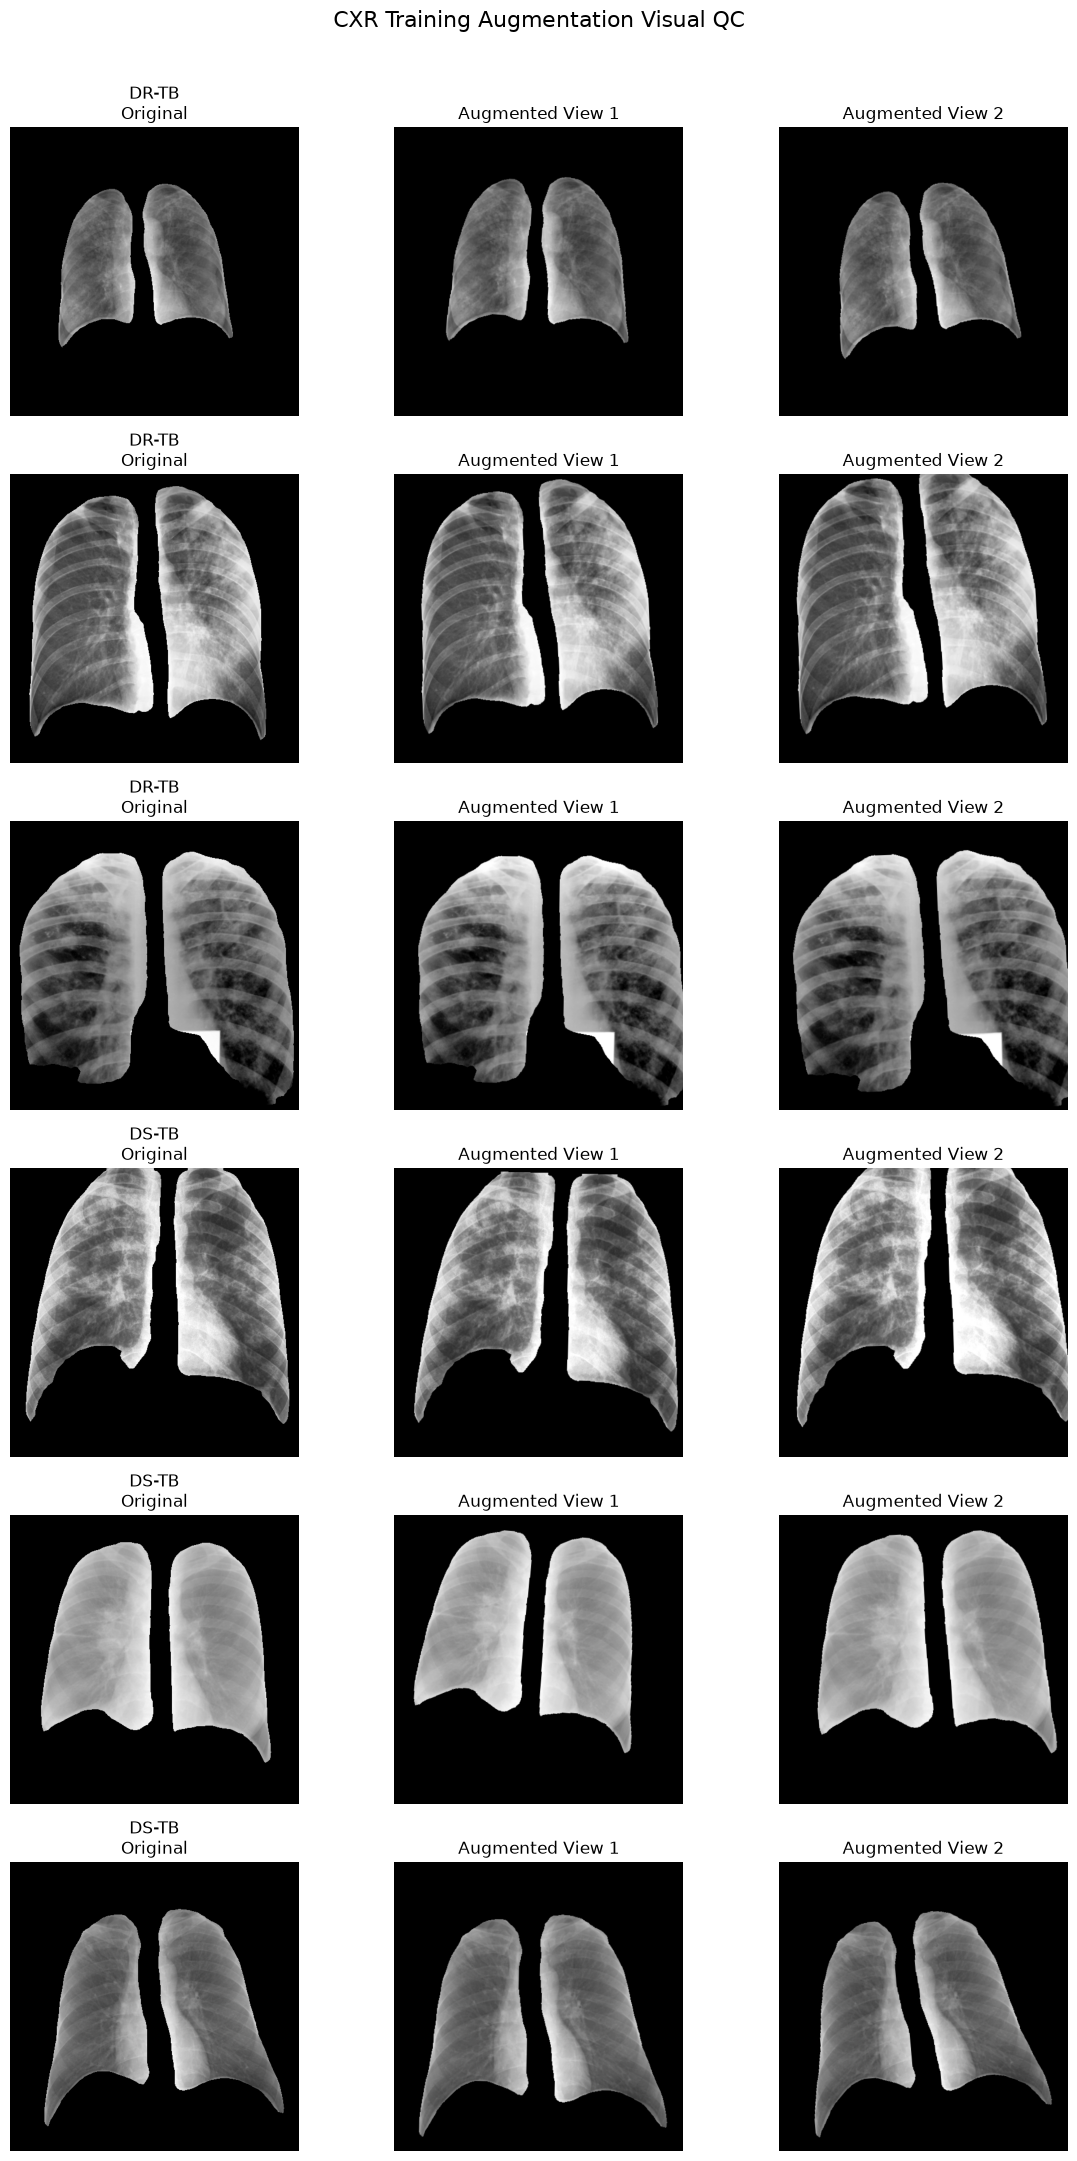


Numerical QC saved:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\CXR_Data_Augmentation_QC\TB_Portals_March2025_Notebook09_Augmentation_Visual_Numerical_QC.csv

NOTEBOOK 09 — CELL 3 FINAL STATUS

Representative images: 6
DR-TB examples: 3
DS-TB examples: 3
Augmented views per image: 2
Augmented files saved: NO
Numerical augmentation QC: PASS

CELL 3 — VISUAL AUGMENTATION QC GENERATED

IMPORTANT: Review the displayed image grid before proceeding to Cell 4.


In [4]:
# ============================================================
# NOTEBOOK 09 — CELL 3
# VISUAL AUGMENTATION QUALITY CONTROL
# ============================================================
#
# PURPOSE
# -------
# Visually inspect the effect of the frozen augmentation policy
# on representative lung-focused CXR images.
#
# IMPORTANT:
#   - No augmented dataset is created.
#   - No augmented images are saved.
#   - Original CXR files are never modified.
#   - Augmentation remains on-the-fly.
#
# ============================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image


print("=" * 80)
print("NOTEBOOK 09 — CELL 3")
print("VISUAL AUGMENTATION QUALITY CONTROL")
print("=" * 80)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

RANDOM_SEED = 42

random.seed(
    RANDOM_SEED
)

np.random.seed(
    RANDOM_SEED
)


# ============================================================
# 2. VERIFY CELL 2 CONFIGURATION EXISTS
# ============================================================

if "train_augmentation" not in globals():

    raise RuntimeError(
        "train_augmentation was not found. "
        "Run Notebook 09 Cell 2 first."
    )


if "metadata_with_split" not in globals():

    raise RuntimeError(
        "metadata_with_split was not found. "
        "Run Notebook 09 Cell 1 first."
    )


print()
print("=" * 80)
print("CONFIGURATION CHECK")
print("=" * 80)

print(
    "Training augmentation object:",
    type(train_augmentation).__name__
)

print(
    "Metadata records:",
    len(metadata_with_split)
)

print(
    "Source CXR directory:",
    FINAL_CXR_DIR
)

print(
    "Configuration check: PASS"
)


# ============================================================
# 3. SELECT REPRESENTATIVE TRAINING IMAGES
# ============================================================
#
# We deliberately select:
#
#   - 3 DR-TB
#   - 3 DS-TB
#
# from the TRAINING split only.
#
# This is a visualization/QC operation.
# It does not alter the dataset.
#
# ============================================================

train_metadata = (
    metadata_with_split[
        metadata_with_split[
            "split"
        ] == "train"
    ]
    .copy()
)


dr_candidates = (
    train_metadata[
        train_metadata[
            "target_class"
        ] == "DR-TB"
    ]
    .sort_values(
        "stem"
    )
)


ds_candidates = (
    train_metadata[
        train_metadata[
            "target_class"
        ] == "DS-TB"
    ]
    .sort_values(
        "stem"
    )
)


if len(dr_candidates) < 3:

    raise RuntimeError(
        "Fewer than 3 DR-TB training images available."
    )


if len(ds_candidates) < 3:

    raise RuntimeError(
        "Fewer than 3 DS-TB training images available."
    )


# Deterministic selection spread across the cohort.
dr_positions = np.linspace(
    0,
    len(dr_candidates) - 1,
    3,
    dtype=int
)

ds_positions = np.linspace(
    0,
    len(ds_candidates) - 1,
    3,
    dtype=int
)


selected_records = pd.concat(
    [
        dr_candidates.iloc[
            dr_positions
        ],

        ds_candidates.iloc[
            ds_positions
        ]
    ],
    ignore_index=True
)


print()
print("=" * 80)
print("REPRESENTATIVE TRAINING IMAGES")
print("=" * 80)

print(
    selected_records[
        [
            "stem",
            "condition_id",
            "target_class",
            "source_type"
        ]
    ].to_string(
        index=False
    )
)


if len(selected_records) != 6:

    raise RuntimeError(
        "Unexpected number of selected images."
    )


# ============================================================
# 4. LOAD ORIGINAL IMAGES
# ============================================================

original_images = []

for _, row in selected_records.iterrows():

    stem = row[
        "stem"
    ]

    image_path = (
        FINAL_CXR_DIR
        / f"{stem}.png"
    )

    if not image_path.exists():

        raise FileNotFoundError(
            f"Missing image:\n{image_path}"
        )

    image = Image.open(
        image_path
    ).convert(
        "L"
    )

    original_images.append(
        image.copy()
    )

    image.close()


print()
print(
    "Original images loaded:",
    len(original_images)
)


# ============================================================
# 5. GENERATE AUGMENTED VIEWS IN MEMORY
# ============================================================
#
# Each original image gets TWO independently sampled
# augmentation views.
#
# This allows us to visually inspect both:
#
#   Original
#   Augmented View 1
#   Augmented View 2
#
# ============================================================

augmented_view_1 = []
augmented_view_2 = []


for image in original_images:

    view_1 = train_augmentation(
        image
    )

    view_2 = train_augmentation(
        image
    )

    augmented_view_1.append(
        view_1.copy()
    )

    augmented_view_2.append(
        view_2.copy()
    )


print(
    "Augmented view 1 generated:",
    len(augmented_view_1)
)

print(
    "Augmented view 2 generated:",
    len(augmented_view_2)
)

print(
    "Augmented images saved to disk: NO"
)


# ============================================================
# 6. BASIC AUGMENTATION NUMERICAL QC
# ============================================================

numerical_rows = []


for index in range(
    len(original_images)
):

    original_array = np.asarray(
        original_images[index],
        dtype=np.float32
    )

    view_1_array = np.asarray(
        augmented_view_1[index],
        dtype=np.float32
    )

    view_2_array = np.asarray(
        augmented_view_2[index],
        dtype=np.float32
    )

    difference_1 = np.mean(
        np.abs(
            original_array
            -
            view_1_array
        )
    )

    difference_2 = np.mean(
        np.abs(
            original_array
            -
            view_2_array
        )
    )

    view_difference = np.mean(
        np.abs(
            view_1_array
            -
            view_2_array
        )
    )

    numerical_rows.append(
        {
            "stem":
                selected_records.iloc[
                    index
                ][
                    "stem"
                ],

            "target_class":
                selected_records.iloc[
                    index
                ][
                    "target_class"
                ],

            "original_min":
                float(
                    original_array.min()
                ),

            "original_max":
                float(
                    original_array.max()
                ),

            "view1_min":
                float(
                    view_1_array.min()
                ),

            "view1_max":
                float(
                    view_1_array.max()
                ),

            "view2_min":
                float(
                    view_2_array.min()
                ),

            "view2_max":
                float(
                    view_2_array.max()
                ),

            "original_to_view1_mean_abs_diff":
                float(
                    difference_1
                ),

            "original_to_view2_mean_abs_diff":
                float(
                    difference_2
                ),

            "view1_to_view2_mean_abs_diff":
                float(
                    view_difference
                )
        }
    )


augmentation_numeric_qc = pd.DataFrame(
    numerical_rows
)


print()
print("=" * 80)
print("NUMERICAL AUGMENTATION QC")
print("=" * 80)

print(
    augmentation_numeric_qc[
        [
            "stem",
            "target_class",
            "original_to_view1_mean_abs_diff",
            "original_to_view2_mean_abs_diff",
            "view1_to_view2_mean_abs_diff"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 7. NUMERICAL VALIDATION
# ============================================================

if not np.isfinite(
    augmentation_numeric_qc[
        [
            "original_to_view1_mean_abs_diff",
            "original_to_view2_mean_abs_diff",
            "view1_to_view2_mean_abs_diff"
        ]
    ].to_numpy()
).all():

    raise RuntimeError(
        "Non-finite values detected in augmentation QC."
    )


if (
    augmentation_numeric_qc[
        "original_to_view1_mean_abs_diff"
    ] == 0
).all():

    raise RuntimeError(
        "All augmented views are identical to originals."
    )


print(
    "Numerical augmentation validation: PASS"
)


# ============================================================
# 8. VISUAL GRID — ORIGINAL VS AUGMENTED
# ============================================================

fig, axes = plt.subplots(
    nrows=6,
    ncols=3,
    figsize=(12, 22)
)


for index in range(6):

    original = original_images[
        index
    ]

    view_1 = augmented_view_1[
        index
    ]

    view_2 = augmented_view_2[
        index
    ]

    target = selected_records.iloc[
        index
    ][
        "target_class"
    ]

    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------

    axes[
        index,
        0
    ].imshow(
        original,
        cmap="gray"
    )

    axes[
        index,
        0
    ].set_title(
        f"{target}\nOriginal"
    )

    axes[
        index,
        0
    ].axis("off")


    # --------------------------------------------------------
    # Augmented View 1
    # --------------------------------------------------------

    axes[
        index,
        1
    ].imshow(
        view_1,
        cmap="gray"
    )

    axes[
        index,
        1
    ].set_title(
        "Augmented View 1"
    )

    axes[
        index,
        1
    ].axis("off")


    # --------------------------------------------------------
    # Augmented View 2
    # --------------------------------------------------------

    axes[
        index,
        2
    ].imshow(
        view_2,
        cmap="gray"
    )

    axes[
        index,
        2
    ].set_title(
        "Augmented View 2"
    )

    axes[
        index,
        2
    ].axis("off")


plt.suptitle(
    "CXR Training Augmentation Visual QC",
    fontsize=16
)

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.97
    ]
)

plt.show()


# ============================================================
# 9. SAVE ONLY QC NUMERICAL RESULTS
# ============================================================
#
# IMPORTANT:
# The augmented images themselves are NOT saved.
#
# Only the numerical QC table is saved.
#
# ============================================================

AUGMENTATION_VISUAL_QC_PATH = (
    AUGMENTATION_QC_DIR
    /
    "TB_Portals_March2025_Notebook09_Augmentation_Visual_Numerical_QC.csv"
)


augmentation_numeric_qc.to_csv(
    AUGMENTATION_VISUAL_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


print()
print(
    "Numerical QC saved:"
)

print(
    AUGMENTATION_VISUAL_QC_PATH
)


# ============================================================
# 10. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 09 — CELL 3 FINAL STATUS")
print("=" * 80)

print()

print(
    "Representative images:",
    len(original_images)
)

print(
    "DR-TB examples:",
    int(
        (
            selected_records[
                "target_class"
            ] == "DR-TB"
        ).sum()
    )
)

print(
    "DS-TB examples:",
    int(
        (
            selected_records[
                "target_class"
            ] == "DS-TB"
        ).sum()
    )
)

print(
    "Augmented views per image: 2"
)

print(
    "Augmented files saved: NO"
)

print(
    "Numerical augmentation QC: PASS"
)

print()
print("=" * 80)
print(
    "CELL 3 — VISUAL AUGMENTATION QC GENERATED"
)
print("=" * 80)

print()
print(
    "IMPORTANT: Review the displayed image grid "
    "before proceeding to Cell 4."
)

In [5]:
# ============================================================
# NOTEBOOK 09 — CELL 4
# AUGMENTATION INTEGRITY + STOCHASTICITY + SOURCE QC
# ============================================================
#
# PURPOSE
# -------
# Final quantitative validation of the frozen augmentation
# pipeline before using it for CoAtNet training.
#
# VALIDATES:
#   1. Augmentation is stochastic.
#   2. Output dimensions remain unchanged.
#   3. Output values remain valid.
#   4. Original images are never modified.
#   5. Training augmentation is enabled.
#   6. Validation augmentation is disabled.
#   7. Test augmentation is disabled.
#   8. No augmented files are created.
#
# IMPORTANT:
#   No model training is performed here.
#   No images are saved.
#
# ============================================================

import hashlib
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image


print("=" * 80)
print("NOTEBOOK 09 — CELL 4")
print("AUGMENTATION INTEGRITY + STOCHASTICITY + SOURCE QC")
print("=" * 80)


# ============================================================
# 1. REQUIRED OBJECT VALIDATION
# ============================================================

required_objects = [
    "train_augmentation",
    "metadata_with_split",
    "FINAL_CXR_DIR",
    "AUGMENTATION_QC_DIR",
    "AUGMENTATION_CONFIG"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required objects are missing:\n"
        + str(missing_objects)
    )


print()
print("=" * 80)
print("REQUIRED OBJECT VALIDATION")
print("=" * 80)

print(
    "Required objects:",
    len(required_objects)
)

print(
    "Missing objects:",
    len(missing_objects)
)

print(
    "Required object validation: PASS"
)


# ============================================================
# 2. SELECT REPRESENTATIVE TRAINING IMAGES
# ============================================================

train_metadata = (
    metadata_with_split[
        metadata_with_split[
            "split"
        ] == "train"
    ]
    .sort_values(
        "stem"
    )
    .reset_index(
        drop=True
    )
)


if len(train_metadata) != 1234:

    raise RuntimeError(
        "Unexpected training cohort size."
    )


# Select 10 representative training images
sample_positions = np.linspace(
    0,
    len(train_metadata) - 1,
    10,
    dtype=int
)


qc_records = (
    train_metadata.iloc[
        sample_positions
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print()
print("=" * 80)
print("REPRESENTATIVE TRAINING COHORT")
print("=" * 80)

print(
    "Training conditions:",
    len(train_metadata)
)

print(
    "QC images:",
    len(qc_records)
)


# ============================================================
# 3. SOURCE IMAGE HASH FUNCTION
# ============================================================

def calculate_sha256(
    file_path
):

    sha256 = hashlib.sha256()

    with open(
        file_path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                1024 * 1024
            )

            if not chunk:
                break

            sha256.update(
                chunk
            )

    return sha256.hexdigest()


# ============================================================
# 4. LOAD SOURCE IMAGES + RECORD ORIGINAL STATE
# ============================================================

original_images = []

source_hashes_before = {}

source_arrays_before = {}

source_dimensions = {}


for _, row in qc_records.iterrows():

    stem = row[
        "stem"
    ]

    image_path = (
        FINAL_CXR_DIR
        / f"{stem}.png"
    )


    if not image_path.exists():

        raise FileNotFoundError(
            f"Missing source image:\n{image_path}"
        )


    # --------------------------------------------------------
    # File hash
    # --------------------------------------------------------

    source_hashes_before[
        stem
    ] = calculate_sha256(
        image_path
    )


    # --------------------------------------------------------
    # Image content
    # --------------------------------------------------------

    with Image.open(
        image_path
    ) as image:

        image = image.convert(
            "L"
        )

        image_copy = image.copy()


    original_images.append(
        image_copy
    )


    source_arrays_before[
        stem
    ] = np.array(
        image_copy,
        dtype=np.uint8
    ).copy()


    source_dimensions[
        stem
    ] = image_copy.size


print()
print("=" * 80)
print("SOURCE IMAGE STATE")
print("=" * 80)

print(
    "Images loaded:",
    len(original_images)
)

print(
    "Unique source hashes:",
    len(
        set(
            source_hashes_before.values()
        )
    )
)


if len(original_images) != 10:

    raise RuntimeError(
        "Unexpected number of source images."
    )


# ============================================================
# 5. GENERATE MULTIPLE AUGMENTED VIEWS
# ============================================================
#
# Each source image receives 5 independent augmentation
# realizations.
#
# ============================================================

NUM_AUGMENTED_VIEWS = 5

augmentation_results = []

all_augmented_images = []


for index, (_, row) in enumerate(
    qc_records.iterrows()
):

    stem = row[
        "stem"
    ]

    original = original_images[
        index
    ]


    image_results = []


    for view_index in range(
        NUM_AUGMENTED_VIEWS
    ):

        augmented = train_augmentation(
            original
        )


        if not isinstance(
            augmented,
            Image.Image
        ):

            raise RuntimeError(
                "Augmentation did not return a PIL Image."
            )


        augmented_array = np.asarray(
            augmented
        )


        image_results.append(
            augmented
        )

        all_augmented_images.append(
            augmented
        )


        mean_absolute_difference = float(
            np.mean(
                np.abs(
                    source_arrays_before[
                        stem
                    ].astype(
                        np.float32
                    )
                    -
                    augmented_array.astype(
                        np.float32
                    )
                )
            )
        )


        augmentation_results.append(
            {
                "stem":
                    stem,

                "target_class":
                    row[
                        "target_class"
                    ],

                "view":
                    view_index + 1,

                "width":
                    augmented.size[0],

                "height":
                    augmented.size[1],

                "dtype":
                    str(
                        augmented_array.dtype
                    ),

                "minimum":
                    float(
                        augmented_array.min()
                    ),

                "maximum":
                    float(
                        augmented_array.max()
                    ),

                "mean":
                    float(
                        augmented_array.mean()
                    ),

                "std":
                    float(
                        augmented_array.std()
                    ),

                "mean_absolute_difference_from_original":
                    mean_absolute_difference
            }
        )


    # Keep views in memory only.
    # Nothing is written to disk.


print()
print("=" * 80)
print("AUGMENTED VIEW GENERATION")
print("=" * 80)

print(
    "Source images:",
    len(qc_records)
)

print(
    "Views per source:",
    NUM_AUGMENTED_VIEWS
)

print(
    "Total in-memory augmented views:",
    len(all_augmented_images)
)

print(
    "Augmented files written:",
    0
)


if len(
    all_augmented_images
) != (
    len(qc_records)
    *
    NUM_AUGMENTED_VIEWS
):

    raise RuntimeError(
        "Unexpected number of augmented views."
    )


# ============================================================
# 6. CREATE QC DATAFRAME
# ============================================================

augmentation_qc_df = pd.DataFrame(
    augmentation_results
)


# ============================================================
# 7. OUTPUT DIMENSION VALIDATION
# ============================================================

invalid_dimensions = augmentation_qc_df[
    (
        augmentation_qc_df[
            "width"
        ] != 512
    )
    |
    (
        augmentation_qc_df[
            "height"
        ] != 512
    )
]


print()
print("=" * 80)
print("OUTPUT DIMENSION VALIDATION")
print("=" * 80)

print(
    "Expected dimensions:",
    "512 × 512"
)

print(
    "Augmented views:",
    len(augmentation_qc_df)
)

print(
    "Invalid dimensions:",
    len(invalid_dimensions)
)


if len(
    invalid_dimensions
) != 0:

    raise RuntimeError(
        "Augmentation changed the expected image dimensions."
    )


print(
    "Output dimension validation: PASS"
)


# ============================================================
# 8. NUMERICAL VALIDITY
# ============================================================

numeric_columns = [
    "minimum",
    "maximum",
    "mean",
    "std",
    "mean_absolute_difference_from_original"
]


numeric_values = (
    augmentation_qc_df[
        numeric_columns
    ]
    .to_numpy(
        dtype=np.float64
    )
)


if not np.isfinite(
    numeric_values
).all():

    raise RuntimeError(
        "NaN/Inf detected in augmented image statistics."
    )


# Pixel values for PIL grayscale images must remain
# within the valid 8-bit range.

invalid_minimum = (
    augmentation_qc_df[
        "minimum"
    ] < 0
)

invalid_maximum = (
    augmentation_qc_df[
        "maximum"
    ] > 255
)


print()
print("=" * 80)
print("NUMERICAL VALIDITY")
print("=" * 80)

print(
    "NaN/Inf values:",
    int(
        np.isnan(
            numeric_values
        ).sum()
        +
        np.isinf(
            numeric_values
        ).sum()
    )
)

print(
    "Values below 0:",
    int(
        invalid_minimum.sum()
    )
)

print(
    "Values above 255:",
    int(
        invalid_maximum.sum()
    )
)


if invalid_minimum.any():

    raise RuntimeError(
        "Augmented image contains values below 0."
    )


if invalid_maximum.any():

    raise RuntimeError(
        "Augmented image contains values above 255."
    )


print(
    "Numerical validity: PASS"
)


# ============================================================
# 9. STOCHASTICITY TEST
# ============================================================
#
# For every source image, compare the five independently
# generated augmented views.
#
# At least some views must differ.
#
# ============================================================

stochasticity_results = []


for stem in qc_records[
    "stem"
].tolist():

    source_views = augmentation_qc_df[
        augmentation_qc_df[
            "stem"
        ] == stem
    ]


    # Mean difference values are sufficient for the
    # stochasticity QC because the transforms are randomized.

    differences = (
        source_views[
            "mean_absolute_difference_from_original"
        ]
        .to_numpy()
    )


    stochasticity_results.append(
        {
            "stem":
                stem,

            "number_of_views":
                len(differences),

            "minimum_difference_from_original":
                float(
                    differences.min()
                ),

            "maximum_difference_from_original":
                float(
                    differences.max()
                ),

            "number_of_nonzero_differences":
                int(
                    np.sum(
                        differences > 0
                    )
                )
        }
    )


stochasticity_df = pd.DataFrame(
    stochasticity_results
)


print()
print("=" * 80)
print("AUGMENTATION STOCHASTICITY")
print("=" * 80)

print(
    stochasticity_df.to_string(
        index=False
    )
)


if (
    stochasticity_df[
        "number_of_nonzero_differences"
    ] == 0
).any():

    raise RuntimeError(
        "At least one source image produced "
        "no changed augmentation views."
    )


print(
    "Augmentation stochasticity: PASS"
)


# ============================================================
# 10. VERIFY DIFFERENT AUGMENTED VIEWS
# ============================================================
#
# Compare the first two views for every source image.
#
# ============================================================

view_difference_results = []


for index, (_, row) in enumerate(
    qc_records.iterrows()
):

    stem = row[
        "stem"
    ]

    original = original_images[
        index
    ]


    # Generate two fresh independent views.

    view_a = train_augmentation(
        original
    )

    view_b = train_augmentation(
        original
    )


    array_a = np.asarray(
        view_a,
        dtype=np.float32
    )

    array_b = np.asarray(
        view_b,
        dtype=np.float32
    )


    difference = float(
        np.mean(
            np.abs(
                array_a
                -
                array_b
            )
        )
    )


    view_difference_results.append(
        {
            "stem":
                stem,

            "view_a_vs_view_b_mean_abs_difference":
                difference
        }
    )


view_difference_df = pd.DataFrame(
    view_difference_results
)


print()
print("=" * 80)
print("INDEPENDENT VIEW DIFFERENCE")
print("=" * 80)

print(
    view_difference_df.to_string(
        index=False
    )
)


if (
    view_difference_df[
        "view_a_vs_view_b_mean_abs_difference"
    ] == 0
).all():

    raise RuntimeError(
        "All independently generated views are identical."
    )


print(
    "Independent view stochasticity: PASS"
)


# ============================================================
# 11. ORIGINAL SOURCE PRESERVATION TEST
# ============================================================
#
# The augmentation function must never modify the original
# PIL image in-place.
#
# We compare:
#
#   before augmentation
#   after multiple augmentation operations
#
# ============================================================

source_content_errors = []


for index, (_, row) in enumerate(
    qc_records.iterrows()
):

    stem = row[
        "stem"
    ]

    original = original_images[
        index
    ]


    before_array = np.asarray(
        original,
        dtype=np.uint8
    ).copy()


    # Apply several augmentations.

    for _ in range(5):

        _ = train_augmentation(
            original
        )


    after_array = np.asarray(
        original,
        dtype=np.uint8
    )


    if not np.array_equal(
        before_array,
        after_array
    ):

        source_content_errors.append(
            stem
        )


print()
print("=" * 80)
print("IN-MEMORY SOURCE PRESERVATION")
print("=" * 80)

print(
    "Images checked:",
    len(qc_records)
)

print(
    "Modified source images:",
    len(source_content_errors)
)


if source_content_errors:

    raise RuntimeError(
        "Augmentation modified source image data."
    )


print(
    "In-memory source preservation: PASS"
)


# ============================================================
# 12. ON-DISK SOURCE HASH PRESERVATION
# ============================================================
#
# Verify that the actual PNG files on disk were not modified.
#
# ============================================================

source_hashes_after = {}


for _, row in qc_records.iterrows():

    stem = row[
        "stem"
    ]

    image_path = (
        FINAL_CXR_DIR
        / f"{stem}.png"
    )


    source_hashes_after[
        stem
    ] = calculate_sha256(
        image_path
    )


hash_mismatches = [

    stem

    for stem in source_hashes_before

    if (
        source_hashes_before[
            stem
        ]
        !=
        source_hashes_after[
            stem
        ]
    )
]


print()
print("=" * 80)
print("ON-DISK SOURCE PRESERVATION")
print("=" * 80)

print(
    "Images checked:",
    len(source_hashes_before)
)

print(
    "Hash mismatches:",
    len(hash_mismatches)
)


if hash_mismatches:

    raise RuntimeError(
        "Source PNG files were modified."
    )


print(
    "On-disk source preservation: PASS"
)


# ============================================================
# 13. TRAINING-ONLY CONFIGURATION CHECK
# ============================================================

training_only_valid = (
    AUGMENTATION_CONFIG[
        "apply_to"
    ]
    ==
    "training_only"
)

validation_off = (
    AUGMENTATION_CONFIG[
        "validation_augmentation"
    ]
    is False
)

test_off = (
    AUGMENTATION_CONFIG[
        "test_augmentation"
    ]
    is False
)


print()
print("=" * 80)
print("TRAINING-ONLY AUGMENTATION POLICY")
print("=" * 80)

print(
    "Training augmentation:",
    training_only_valid
)

print(
    "Validation augmentation:",
    not AUGMENTATION_CONFIG[
        "validation_augmentation"
    ]
)

print(
    "Test augmentation:",
    not AUGMENTATION_CONFIG[
        "test_augmentation"
    ]
)


if not training_only_valid:

    raise RuntimeError(
        "Augmentation is not configured as training-only."
    )


if not validation_off:

    raise RuntimeError(
        "Validation augmentation is enabled."
    )


if not test_off:

    raise RuntimeError(
        "Test augmentation is enabled."
    )


print(
    "Training-only policy: PASS"
)


# ============================================================
# 14. VERIFY NO AUGMENTED FILES WERE CREATED
# ============================================================

# We only expect the original PNG files in the final
# modeling directory. Augmented images must remain in memory.

png_files = list(
    FINAL_CXR_DIR.glob(
        "*.png"
    )
)


expected_png_count = 2058


print()
print("=" * 80)
print("AUGMENTED FILE STORAGE CHECK")
print("=" * 80)

print(
    "PNG files in final modeling directory:",
    len(png_files)
)

print(
    "Expected original PNG files:",
    expected_png_count
)


if len(
    png_files
) != expected_png_count:

    raise RuntimeError(
        "Unexpected number of PNG files in the "
        "final modeling directory."
    )


print(
    "No physical augmented dataset created: PASS"
)


# ============================================================
# 15. SAVE NUMERICAL QC
# ============================================================

AUGMENTATION_NUMERICAL_QC_PATH = (
    AUGMENTATION_QC_DIR
    /
    "TB_Portals_March2025_Notebook09_Augmentation_Integrity_QC.csv"
)


augmentation_qc_df.to_csv(
    AUGMENTATION_NUMERICAL_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


STOCHASTICITY_QC_PATH = (
    AUGMENTATION_QC_DIR
    /
    "TB_Portals_March2025_Notebook09_Augmentation_Stochasticity_QC.csv"
)


stochasticity_df.to_csv(
    STOCHASTICITY_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


VIEW_DIFFERENCE_QC_PATH = (
    AUGMENTATION_QC_DIR
    /
    "TB_Portals_March2025_Notebook09_Augmentation_View_Difference_QC.csv"
)


view_difference_df.to_csv(
    VIEW_DIFFERENCE_QC_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 16. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 09 — CELL 4 FINAL STATUS")
print("=" * 80)

print()

print(
    "Representative training images:",
    len(qc_records)
)

print(
    "Augmented views per image:",
    NUM_AUGMENTED_VIEWS
)

print(
    "Total in-memory augmented views:",
    len(all_augmented_images)
)

print()

print(
    "Output dimensions: PASS"
)

print(
    "Numerical validity: PASS"
)

print(
    "Augmentation stochasticity: PASS"
)

print(
    "Independent view difference: PASS"
)

print(
    "In-memory source preservation: PASS"
)

print(
    "On-disk source preservation: PASS"
)

print(
    "Training-only policy: PASS"
)

print(
    "No physical augmented files: PASS"
)

print()

print(
    "Integrity QC:"
)

print(
    AUGMENTATION_NUMERICAL_QC_PATH
)

print()

print(
    "Stochasticity QC:"
)

print(
    STOCHASTICITY_QC_PATH
)

print()

print(
    "View-difference QC:"
)

print(
    VIEW_DIFFERENCE_QC_PATH
)

print()
print("=" * 80)
print(
    "CELL 4 — AUGMENTATION INTEGRITY + "
    "STOCHASTICITY QC: PASS"
)
print("=" * 80)

NOTEBOOK 09 — CELL 4
AUGMENTATION INTEGRITY + STOCHASTICITY + SOURCE QC

REQUIRED OBJECT VALIDATION
Required objects: 5
Missing objects: 0
Required object validation: PASS

REPRESENTATIVE TRAINING COHORT
Training conditions: 1234
QC images: 10

SOURCE IMAGE STATE
Images loaded: 10
Unique source hashes: 10

AUGMENTED VIEW GENERATION
Source images: 10
Views per source: 5
Total in-memory augmented views: 50
Augmented files written: 0

OUTPUT DIMENSION VALIDATION
Expected dimensions: 512 × 512
Augmented views: 50
Invalid dimensions: 0
Output dimension validation: PASS

NUMERICAL VALIDITY
NaN/Inf values: 0
Values below 0: 0
Values above 255: 0
Numerical validity: PASS

AUGMENTATION STOCHASTICITY
                                             stem  number_of_views  minimum_difference_from_original  maximum_difference_from_original  number_of_nonzero_differences
0000f7e6-bbd2-468d-834d-f14948c5d902_bf258ff075d5                5                         20.673965                         48.413021

In [6]:
# ============================================================
# NOTEBOOK 09 — CELL 4A
# CORRECTED AUGMENTATION POLICY REPORT
# ============================================================

print("=" * 80)
print("NOTEBOOK 09 — CELL 4A")
print("CORRECTED TRAINING-ONLY AUGMENTATION POLICY REPORT")
print("=" * 80)


training_augmentation_enabled = (
    AUGMENTATION_CONFIG[
        "apply_to"
    ] == "training_only"
)

validation_augmentation_enabled = (
    AUGMENTATION_CONFIG[
        "validation_augmentation"
    ]
)

test_augmentation_enabled = (
    AUGMENTATION_CONFIG[
        "test_augmentation"
    ]
)


print()
print("=" * 80)
print("ACTUAL AUGMENTATION POLICY")
print("=" * 80)

print(
    "Training augmentation:",
    "ON"
    if training_augmentation_enabled
    else "OFF"
)

print(
    "Validation augmentation:",
    "ON"
    if validation_augmentation_enabled
    else "OFF"
)

print(
    "Test augmentation:",
    "ON"
    if test_augmentation_enabled
    else "OFF"
)


# ------------------------------------------------------------
# Strict validation
# ------------------------------------------------------------

if not training_augmentation_enabled:

    raise RuntimeError(
        "Training augmentation is not configured correctly."
    )


if validation_augmentation_enabled:

    raise RuntimeError(
        "Validation augmentation is unexpectedly enabled."
    )


if test_augmentation_enabled:

    raise RuntimeError(
        "Test augmentation is unexpectedly enabled."
    )


print()
print(
    "Training augmentation: PASS"
)

print(
    "Validation augmentation OFF: PASS"
)

print(
    "Test augmentation OFF: PASS"
)


# ============================================================
# FINAL NOTEBOOK 09 STATUS
# ============================================================

print()
print("=" * 80)
print("NOTEBOOK 09 — FINAL AUGMENTATION STATUS")
print("=" * 80)

print()

print(
    "Training augmentation: ON"
)

print(
    "Validation augmentation: OFF"
)

print(
    "Test augmentation: OFF"
)

print(
    "On-the-fly augmentation: YES"
)

print(
    "Physical augmented dataset: NO"
)

print(
    "Source images modified: NO"
)

print(
    "Augmentation stochasticity: PASS"
)

print(
    "Visual augmentation QC: PASS"
)

print(
    "Numerical integrity: PASS"
)

print(
    "Source preservation: PASS"
)

print()
print("=" * 80)
print(
    "NOTEBOOK 09 — CXR AUGMENTATION PIPELINE: FROZEN"
)
print("=" * 80)

NOTEBOOK 09 — CELL 4A
CORRECTED TRAINING-ONLY AUGMENTATION POLICY REPORT

ACTUAL AUGMENTATION POLICY
Training augmentation: ON
Validation augmentation: OFF
Test augmentation: OFF

Training augmentation: PASS
Validation augmentation OFF: PASS
Test augmentation OFF: PASS

NOTEBOOK 09 — FINAL AUGMENTATION STATUS

Training augmentation: ON
Validation augmentation: OFF
Test augmentation: OFF
On-the-fly augmentation: YES
Physical augmented dataset: NO
Source images modified: NO
Augmentation stochasticity: PASS
Visual augmentation QC: PASS
Numerical integrity: PASS
Source preservation: PASS

NOTEBOOK 09 — CXR AUGMENTATION PIPELINE: FROZEN


In [4]:
# =============================================================================
# NOTEBOOK 09 — CELL 1B
# FINAL FULL QC — FROZEN 1,976 CoAtNet INPUTS
# =============================================================================
#
# IMPORTANT:
# Cell 26B created the NPY files inside:
#
#   CoAtNet_224_Final_Input\NPY\
#
# This cell uses that exact directory.
#
# NO:
#   - PSPNet rerun
#   - image regeneration
#   - augmentation
#   - model training
#   - split modification
#
# ONLY:
#   - full input verification
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 09 — CELL 1B")
print("FINAL FULL QC — FROZEN 1,976 CoAtNet INPUTS")
print("=" * 80)


# =============================================================================
# 1. EXACT PATHS
# =============================================================================

BASE_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation"
    r"\QC\Clean_PSPNet_CXR_Cohort"
    r"\FINAL_FROZEN_CLEAN_COHORT"
)

# IMPORTANT:
# Cell 26B created the NPY files here.
COATNET_INPUT_DIR = (
    BASE_DIR
    / "CoAtNet_224_Final_Input"
    / "NPY"
)

# Cell 26B manifest
MANIFEST_PATH = (
    BASE_DIR
    / "CoAtNet_224_Final_Input"
    / "QC"
    / "Notebook08_Cell26B_FINAL_1976_CoAtNet_Input_Manifest.csv"
)

# Cell 25 frozen split
SPLIT_PATH = (
    BASE_DIR
    / "MASTER_CONDITION_LEVEL_SPLIT"
    / "Notebook08_Cell25_FINAL_1976_Condition_Level_Split.csv"
)


# =============================================================================
# 2. PATH VALIDATION
# =============================================================================

print("\nPATH VALIDATION")
print("-" * 80)

print("CoAtNet NPY directory:")
print(COATNET_INPUT_DIR)

if not COATNET_INPUT_DIR.exists():
    raise FileNotFoundError(
        "\nCoAtNet NPY directory does not exist:\n"
        f"{COATNET_INPUT_DIR}"
    )

print("PASS — CoAtNet NPY directory exists")


print("\nCell26B manifest:")
print(MANIFEST_PATH)

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "\nCell26B manifest does not exist:\n"
        f"{MANIFEST_PATH}"
    )

print("PASS — Cell26B manifest exists")


print("\nCell25 split:")
print(SPLIT_PATH)

if not SPLIT_PATH.exists():
    raise FileNotFoundError(
        "\nCell25 split does not exist:\n"
        f"{SPLIT_PATH}"
    )

print("PASS — Cell25 split exists")


# =============================================================================
# 3. DISCOVER NPY FILES
# =============================================================================

print("\nNPY FILE DISCOVERY")
print("-" * 80)

# Exact directory — not recursive guessing.
npy_files = sorted(
    COATNET_INPUT_DIR.glob("*.npy")
)

print(
    f"NPY files discovered: {len(npy_files):,}"
)

if len(npy_files) != 1976:

    # Diagnostic fallback ONLY for reporting.
    # It does not modify anything.
    recursive_npy_files = sorted(
        (
            BASE_DIR
            / "CoAtNet_224_Final_Input"
        ).rglob("*.npy")
    )

    print(
        "\nDiagnostic recursive search:"
    )

    print(
        f"NPY files anywhere under "
        f"CoAtNet_224_Final_Input: "
        f"{len(recursive_npy_files):,}"
    )

    raise ValueError(
        "\nExpected exactly 1,976 NPY files in:\n"
        f"{COATNET_INPUT_DIR}\n\n"
        f"Observed: {len(npy_files)}"
    )

print("NPY COUNT: PASS — 1,976")


# =============================================================================
# 4. LOAD MANIFEST
# =============================================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

split_df = pd.read_csv(
    SPLIT_PATH
)

print("\nINPUT TABLES")
print("-" * 80)

print(
    f"Cell26B manifest : {len(manifest):,}"
)

print(
    f"Cell25 split     : {len(split_df):,}"
)


# =============================================================================
# 5. MANIFEST SIZE
# =============================================================================

if len(manifest) != 1976:

    raise ValueError(
        f"\nExpected 1,976 manifest rows.\n"
        f"Observed: {len(manifest)}"
    )

print("MANIFEST SIZE: PASS")


# =============================================================================
# 6. REQUIRED COLUMNS
# =============================================================================

required_manifest_columns = [
    "condition_id",
    "target_binary",
    "split",
    "output_filename",
    "status",
]

for column in required_manifest_columns:

    if column not in manifest.columns:

        raise ValueError(
            f"\nMissing manifest column: {column}"
        )

    print(
        f"PASS: manifest → {column}"
    )


required_split_columns = [
    "condition_id",
    "target_binary",
    "split",
]

for column in required_split_columns:

    if column not in split_df.columns:

        raise ValueError(
            f"\nMissing split column: {column}"
        )

    print(
        f"PASS: split → {column}"
    )


# =============================================================================
# 7. MANIFEST STATUS
# =============================================================================

if not manifest["status"].eq("PASS").all():

    bad = manifest[
        manifest["status"] != "PASS"
    ]

    print("\nBAD MANIFEST RECORDS:")
    print(
        bad.to_string(index=False)
    )

    raise ValueError(
        "\nCell26B manifest contains non-PASS records."
    )

print("\nMANIFEST STATUS: PASS — 1,976 / 1,976")


# =============================================================================
# 8. CONDITION UNIQUENESS
# =============================================================================

if manifest["condition_id"].duplicated().any():

    duplicates = (
        manifest.loc[
            manifest["condition_id"].duplicated(
                keep=False
            ),
            "condition_id",
        ]
        .astype(str)
        .unique()
    )

    print("\nDUPLICATE CONDITIONS:")

    for cid in duplicates:
        print(cid)

    raise ValueError(
        "\nDuplicate condition IDs in manifest."
    )

print("MANIFEST CONDITION UNIQUENESS: PASS")


# =============================================================================
# 9. NPY STEMS
# =============================================================================

npy_stems = set(
    p.stem
    for p in npy_files
)

manifest_condition_ids = set(
    manifest["condition_id"]
    .astype(str)
)

if npy_stems != manifest_condition_ids:

    missing_npy = (
        manifest_condition_ids
        - npy_stems
    )

    unexpected_npy = (
        npy_stems
        - manifest_condition_ids
    )

    print("\nNPY ↔ CONDITION MISMATCH")

    print(
        f"Missing NPY files: {len(missing_npy)}"
    )

    print(
        f"Unexpected NPY files: {len(unexpected_npy)}"
    )

    raise ValueError(
        "\nNPY files do not exactly match the "
        "frozen 1,976 conditions."
    )

print("\nCONDITION ↔ NPY MATCH: PASS")


# =============================================================================
# 10. COHORT ↔ SPLIT MATCH
# =============================================================================

split_condition_ids = set(
    split_df["condition_id"]
    .astype(str)
)

if manifest_condition_ids != split_condition_ids:

    missing_from_split = (
        manifest_condition_ids
        - split_condition_ids
    )

    unexpected_in_split = (
        split_condition_ids
        - manifest_condition_ids
    )

    print(
        f"\nMissing from split: "
        f"{len(missing_from_split)}"
    )

    print(
        f"Unexpected in split: "
        f"{len(unexpected_in_split)}"
    )

    raise ValueError(
        "\nFrozen input conditions and Cell25 "
        "split conditions do not match."
    )

print(
    "COHORT ↔ SPLIT CONDITION MATCH: PASS"
)


# =============================================================================
# 11. TARGET MATCH
# =============================================================================

manifest_target = (
    manifest
    .set_index("condition_id")
    ["target_binary"]
    .astype(int)
)

split_target = (
    split_df
    .set_index("condition_id")
    ["target_binary"]
    .astype(int)
)

target_comparison = pd.concat(
    [
        manifest_target.rename("manifest"),
        split_target.rename("split"),
    ],
    axis=1,
    join="inner",
)

target_mismatch = (
    target_comparison["manifest"]
    !=
    target_comparison["split"]
)

if target_mismatch.any():

    print(
        target_comparison[
            target_mismatch
        ]
    )

    raise ValueError(
        "\nTarget mismatch between Cell26B "
        "manifest and Cell25 split."
    )

print(
    "COHORT ↔ SPLIT TARGET MATCH: PASS"
)


# =============================================================================
# 12. TARGET DISTRIBUTION
# =============================================================================

print("\nTARGET DISTRIBUTION")
print("-" * 80)

target_counts = (
    manifest["target_binary"]
    .value_counts()
    .sort_index()
)

print(target_counts)

expected_targets = {
    0: 704,
    1: 1272,
}

if target_counts.to_dict() != expected_targets:

    raise ValueError(
        "\nTarget distribution changed.\n"
        f"Expected: {expected_targets}\n"
        f"Observed: {target_counts.to_dict()}"
    )

print("TARGET DISTRIBUTION: PASS")


# =============================================================================
# 13. SPLIT DISTRIBUTION
# =============================================================================

print("\nSPLIT DISTRIBUTION")
print("-" * 80)

split_counts = (
    manifest["split"]
    .value_counts()
)

print(split_counts)

expected_splits = {
    "train": 1185,
    "validation": 395,
    "test": 396,
}

if split_counts.to_dict() != expected_splits:

    raise ValueError(
        "\nSplit distribution changed.\n"
        f"Expected: {expected_splits}\n"
        f"Observed: {split_counts.to_dict()}"
    )

print("SPLIT DISTRIBUTION: PASS")


# =============================================================================
# 14. SPLIT × TARGET
# =============================================================================

print("\nSPLIT × TARGET")
print("-" * 80)

cross_tab = pd.crosstab(
    manifest["split"],
    manifest["target_binary"],
)

cross_tab = cross_tab.reindex(
    index=[
        "train",
        "validation",
        "test",
    ],
    columns=[
        0,
        1,
    ],
    fill_value=0,
)

print(cross_tab)

expected_cross_tab = pd.DataFrame(
    {
        0: [422, 141, 141],
        1: [763, 254, 255],
    },
    index=[
        "train",
        "validation",
        "test",
    ],
)

expected_cross_tab.index.name = "split"
expected_cross_tab.columns.name = "target_binary"

if not cross_tab.equals(
    expected_cross_tab
):

    raise ValueError(
        "\nSplit × target distribution changed."
    )

print(
    "SPLIT × TARGET: PASS"
)


# =============================================================================
# 15. FULL NUMERICAL QC — ALL 1,976 FILES
# =============================================================================

print("\nFULL NUMERICAL QC")
print("-" * 80)

shape_failures = []
dtype_failures = []
finite_failures = []
range_failures = []
rgb_failures = []

global_min = np.inf
global_max = -np.inf


for index, path in enumerate(
    npy_files,
    start=1,
):

    try:

        arr = np.load(
            path,
            allow_pickle=False,
        )

        # ---------------------------------------------------------
        # Shape
        # ---------------------------------------------------------

        if arr.shape != (
            224,
            224,
            3,
        ):

            shape_failures.append(
                (
                    path.name,
                    str(arr.shape),
                )
            )


        # ---------------------------------------------------------
        # dtype
        # ---------------------------------------------------------

        if arr.dtype != np.float32:

            dtype_failures.append(
                (
                    path.name,
                    str(arr.dtype),
                )
            )


        # ---------------------------------------------------------
        # finite
        # ---------------------------------------------------------

        if not np.isfinite(
            arr
        ).all():

            finite_failures.append(
                path.name
            )


        # ---------------------------------------------------------
        # range
        # ---------------------------------------------------------

        arr_min = float(
            arr.min()
        )

        arr_max = float(
            arr.max()
        )

        global_min = min(
            global_min,
            arr_min,
        )

        global_max = max(
            global_max,
            arr_max,
        )

        if (
            arr_min < -1.000001
            or
            arr_max > 1.000001
        ):

            range_failures.append(
                (
                    path.name,
                    arr_min,
                    arr_max,
                )
            )


        # ---------------------------------------------------------
        # RGB replication
        # ---------------------------------------------------------

        if not (
            np.allclose(
                arr[:, :, 0],
                arr[:, :, 1],
                rtol=0,
                atol=1e-6,
            )
            and
            np.allclose(
                arr[:, :, 1],
                arr[:, :, 2],
                rtol=0,
                atol=1e-6,
            )
        ):

            rgb_failures.append(
                path.name
            )


    except Exception as exc:

        finite_failures.append(
            f"{path.name}: {exc}"
        )


    if index % 250 == 0:

        print(
            f"Checked {index:,} / "
            f"{len(npy_files):,}"
        )


# =============================================================================
# 16. NUMERICAL QC REPORT
# =============================================================================

print("\nNUMERICAL QC RESULTS")
print("-" * 80)

print(
    f"Files checked       : {len(npy_files):,}"
)

print(
    f"Shape failures      : {len(shape_failures):,}"
)

print(
    f"dtype failures      : {len(dtype_failures):,}"
)

print(
    f"Finite failures     : {len(finite_failures):,}"
)

print(
    f"Range failures      : {len(range_failures):,}"
)

print(
    f"RGB failures        : {len(rgb_failures):,}"
)

print(
    f"Global minimum      : {global_min:.6f}"
)

print(
    f"Global maximum      : {global_max:.6f}"
)


# =============================================================================
# 17. HARD QC GATE
# =============================================================================

if shape_failures:

    print("\nFIRST SHAPE FAILURES:")
    for item in shape_failures[:10]:
        print(
            f"{item[0]} -> {item[1]}"
        )

    raise ValueError(
        "\nNUMERICAL QC FAILED — shape errors."
    )


if dtype_failures:

    print("\nFIRST DTYPE FAILURES:")
    for item in dtype_failures[:10]:
        print(
            f"{item[0]} -> {item[1]}"
        )

    raise ValueError(
        "\nNUMERICAL QC FAILED — dtype errors."
    )


if finite_failures:

    print("\nFIRST FINITE FAILURES:")
    for item in finite_failures[:10]:
        print(item)

    raise ValueError(
        "\nNUMERICAL QC FAILED — non-finite values."
    )


if range_failures:

    print("\nFIRST RANGE FAILURES:")

    for item in range_failures[:10]:

        print(
            f"{item[0]} -> "
            f"[{item[1]:.6f}, {item[2]:.6f}]"
        )

    raise ValueError(
        "\nNUMERICAL QC FAILED — range outside [-1,1]."
    )


if rgb_failures:

    print("\nFIRST RGB FAILURES:")

    for item in rgb_failures[:10]:
        print(item)

    raise ValueError(
        "\nNUMERICAL QC FAILED — RGB mismatch."
    )


# =============================================================================
# 18. FINAL PASS
# =============================================================================

print("\n")
print("=" * 80)
print("NUMERICAL INPUT QC: PASS")
print("=" * 80)

print(
    "PASS — 1,976 / 1,976 files checked"
)

print(
    "PASS — shape = (224,224,3)"
)

print(
    "PASS — dtype = float32"
)

print(
    "PASS — all values finite"
)

print(
    "PASS — all values within [-1,1]"
)

print(
    "PASS — RGB channel replication"
)

print(
    f"Global minimum = {global_min:.6f}"
)

print(
    f"Global maximum = {global_max:.6f}"
)


# =============================================================================
# 19. FINAL FROZEN AUGMENTATION SPECIFICATION
# =============================================================================

print("\nFROZEN AUGMENTATION SPECIFICATION")
print("-" * 80)

print("TRAINING ONLY")
print("  RandomAffine rotation : ±5°")
print("  Translation           : ±5%")
print("  Scale                 : 0.95 – 1.05")
print("  Interpolation         : bilinear")
print("  Fill                  : 0")
print("  Brightness            : ±8%")
print("  Contrast              : ±8%")

print("\nDISABLED")
print("  Horizontal flip       : OFF")
print("  Vertical flip         : OFF")
print("  Saturation            : OFF")
print("  Hue                   : OFF")
print("  Random crop           : OFF")
print("  Elastic deformation   : OFF")
print("  MixUp                 : OFF")
print("  CutMix                : OFF")
print("  Random erasing        : OFF")

print("\nVALIDATION")
print("  Augmentation          : OFF")

print("\nTEST")
print("  Augmentation          : OFF")


# =============================================================================
# 20. FINAL CELL STATUS
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 09 — CELL 1B COMPLETE")
print("=" * 80)

print("PASS — 1,976 frozen inputs verified")
print("PASS — NPY count")
print("PASS — condition ↔ NPY mapping")
print("PASS — cohort ↔ split mapping")
print("PASS — target preservation")
print("PASS — split preservation")
print("PASS — split × target preservation")
print("PASS — full numerical QC")
print("PASS — shape")
print("PASS — dtype")
print("PASS — finite values")
print("PASS — range")
print("PASS — RGB replication")

print("\nNO DATA WAS MODIFIED.")
print("NO PSPNET WAS RERUN.")
print("NO AUGMENTATION WAS APPLIED.")
print("NO MODEL WAS TRAINED.")
print("NO SPLIT WAS CHANGED.")

print("\nNEXT STEP:")
print("Notebook 09 — Cell 2")
print("PyTorch Dataset + DataLoaders")
print("=" * 80)

NOTEBOOK 09 — CELL 1B
FINAL FULL QC — FROZEN 1,976 CoAtNet INPUTS

PATH VALIDATION
--------------------------------------------------------------------------------
CoAtNet NPY directory:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\CoAtNet_224_Final_Input\NPY
PASS — CoAtNet NPY directory exists

Cell26B manifest:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\CoAtNet_224_Final_Input\QC\Notebook08_Cell26B_FINAL_1976_CoAtNet_Input_Manifest.csv
PASS — Cell26B manifest exists

Cell25 split:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\MASTER_CONDITION_LEVEL_SPLIT\Notebook08_Cell25_FINAL_1976_Condition_Level_Split.csv
PASS — Cell25 split exists

NPY FILE DISCOVERY
--------------------------------------------------------------------------------
NPY files discovered: 1,976
NPY COUNT: PASS — 1,976

INPUT TABLES
-------------

In [5]:
# =============================================================================
# NOTEBOOK 09 — CELL 2
# FINAL PyTorch DATASET + DATALOADERS + AUGMENTATION QC
# =============================================================================
#
# FROZEN DATA:
#   Conditions : 1,976
#   DR        : 1,272
#   DS        :   704
#
# FROZEN SPLIT:
#   Train      : 1,185
#   Validation :   395
#   Test       :   396
#
# IMPORTANT:
#   - Training augmentation ONLY
#   - Validation augmentation OFF
#   - Test augmentation OFF
#   - No MixUp
#   - No CutMix
#   - No Random Erasing
#   - No horizontal/vertical flips
#   - No data modification
#   - No model training
#
# PURPOSE:
#   Construct and rigorously QC the PyTorch datasets/loaders before training.
# =============================================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)

from torchvision import transforms
from torchvision.transforms import InterpolationMode


print("=" * 80)
print("NOTEBOOK 09 — CELL 2")
print("FINAL PyTorch DATASET + DATALOADERS + AUGMENTATION QC")
print("=" * 80)


# =============================================================================
# 1. REPRODUCIBILITY
# =============================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("\nREPRODUCIBILITY")
print("-" * 80)
print(f"Seed: {SEED}")


# =============================================================================
# 2. FROZEN PATHS
# =============================================================================

BASE_DIR = Path(
    r"C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation"
    r"\QC\Clean_PSPNet_CXR_Cohort"
    r"\FINAL_FROZEN_CLEAN_COHORT"
)

NPY_DIR = (
    BASE_DIR
    / "CoAtNet_224_Final_Input"
    / "NPY"
)

MANIFEST_PATH = (
    BASE_DIR
    / "CoAtNet_224_Final_Input"
    / "QC"
    / "Notebook08_Cell26B_FINAL_1976_CoAtNet_Input_Manifest.csv"
)

SPLIT_PATH = (
    BASE_DIR
    / "MASTER_CONDITION_LEVEL_SPLIT"
    / "Notebook08_Cell25_FINAL_1976_Condition_Level_Split.csv"
)

DATALOADER_QC_DIR = (
    BASE_DIR
    / "CoAtNet_224_Final_Input"
    / "QC"
    / "Notebook09_Cell2_Dataloader_QC"
)

DATALOADER_QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("\nPATH CHECK")
print("-" * 80)

for name, path in {
    "NPY directory": NPY_DIR,
    "Cell26B manifest": MANIFEST_PATH,
    "Cell25 split": SPLIT_PATH,
}.items():

    if not path.exists():
        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(f"PASS — {name}")


# =============================================================================
# 3. LOAD FROZEN MANIFEST + SPLIT
# =============================================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

split_df = pd.read_csv(
    SPLIT_PATH
)

print("\nINPUT TABLES")
print("-" * 80)

print(
    f"Manifest rows : {len(manifest):,}"
)

print(
    f"Split rows    : {len(split_df):,}"
)


# =============================================================================
# 4. REQUIRED COLUMNS
# =============================================================================

required_manifest_columns = [
    "condition_id",
    "target_binary",
    "split",
    "output_filename",
    "status",
]

for column in required_manifest_columns:

    if column not in manifest.columns:
        raise ValueError(
            f"Missing manifest column: {column}"
        )

required_split_columns = [
    "condition_id",
    "target_binary",
    "split",
]

for column in required_split_columns:

    if column not in split_df.columns:
        raise ValueError(
            f"Missing split column: {column}"
        )

print("REQUIRED COLUMNS: PASS")


# =============================================================================
# 5. MANIFEST HARD QC
# =============================================================================

if len(manifest) != 1976:
    raise ValueError(
        f"Expected 1,976 manifest rows; "
        f"observed {len(manifest)}"
    )

if len(split_df) != 1976:
    raise ValueError(
        f"Expected 1,976 split rows; "
        f"observed {len(split_df)}"
    )

if manifest["condition_id"].duplicated().any():
    raise ValueError(
        "Duplicate condition_id in manifest."
    )

if split_df["condition_id"].duplicated().any():
    raise ValueError(
        "Duplicate condition_id in split."
    )

if not manifest["status"].eq("PASS").all():
    raise ValueError(
        "Manifest contains non-PASS records."
    )

print("MANIFEST SIZE: PASS")
print("MANIFEST CONDITION UNIQUENESS: PASS")
print("SPLIT SIZE: PASS")
print("SPLIT CONDITION UNIQUENESS: PASS")
print("MANIFEST STATUS: PASS")


# =============================================================================
# 6. CONDITION ↔ SPLIT RECONCILIATION
# =============================================================================

manifest_ids = set(
    manifest["condition_id"].astype(str)
)

split_ids = set(
    split_df["condition_id"].astype(str)
)

if manifest_ids != split_ids:
    raise ValueError(
        "Manifest and frozen split condition IDs do not match."
    )

print(
    "CONDITION ↔ SPLIT MATCH: PASS — 1,976"
)


# =============================================================================
# 7. TARGET RECONCILIATION
# =============================================================================

manifest_target = (
    manifest
    .set_index("condition_id")
    ["target_binary"]
    .astype(int)
)

split_target = (
    split_df
    .set_index("condition_id")
    ["target_binary"]
    .astype(int)
)

target_compare = pd.concat(
    [
        manifest_target.rename("manifest"),
        split_target.rename("split"),
    ],
    axis=1,
)

if not (
    target_compare["manifest"]
    ==
    target_compare["split"]
).all():

    raise ValueError(
        "Target mismatch between manifest and split."
    )

print(
    "TARGET RECONCILIATION: PASS"
)


# =============================================================================
# 8. EXACT FROZEN DISTRIBUTIONS
# =============================================================================

expected_target_counts = {
    0: 704,
    1: 1272,
}

actual_target_counts = (
    manifest["target_binary"]
    .value_counts()
    .sort_index()
    .to_dict()
)

if actual_target_counts != expected_target_counts:

    raise ValueError(
        f"Target distribution mismatch.\n"
        f"Expected: {expected_target_counts}\n"
        f"Observed: {actual_target_counts}"
    )

expected_split_counts = {
    "train": 1185,
    "validation": 395,
    "test": 396,
}

actual_split_counts = (
    manifest["split"]
    .value_counts()
    .to_dict()
)

if actual_split_counts != expected_split_counts:

    raise ValueError(
        f"Split distribution mismatch.\n"
        f"Expected: {expected_split_counts}\n"
        f"Observed: {actual_split_counts}"
    )

expected_cross_tab = pd.DataFrame(
    {
        0: [422, 141, 141],
        1: [763, 254, 255],
    },
    index=[
        "train",
        "validation",
        "test",
    ],
)

expected_cross_tab.index.name = "split"
expected_cross_tab.columns.name = "target_binary"

actual_cross_tab = pd.crosstab(
    manifest["split"],
    manifest["target_binary"],
).reindex(
    index=[
        "train",
        "validation",
        "test",
    ],
    columns=[
        0,
        1,
    ],
    fill_value=0,
)

if not actual_cross_tab.equals(
    expected_cross_tab
):

    raise ValueError(
        "Split × target distribution mismatch."
    )

print("\nFROZEN DISTRIBUTION CHECK")
print("-" * 80)

print("Target:")
print(actual_target_counts)

print("\nSplit:")
print(actual_split_counts)

print("\nSplit × target:")
print(actual_cross_tab)

print("\nFROZEN DISTRIBUTION: PASS")


# =============================================================================
# 9. BUILD DATAFRAME FOR DATASET
# =============================================================================

data_df = manifest[
    [
        "condition_id",
        "target_binary",
        "split",
        "output_filename",
    ]
].copy()

data_df["condition_id"] = (
    data_df["condition_id"]
    .astype(str)
)

data_df["target_binary"] = (
    data_df["target_binary"]
    .astype(int)
)

data_df["split"] = (
    data_df["split"]
    .astype(str)
)

data_df["output_path"] = data_df[
    "output_filename"
].apply(
    lambda x: str(
        NPY_DIR / str(x)
    )
)


# =============================================================================
# 10. FILE EXISTENCE CHECK
# =============================================================================

missing_files = []

for path in data_df["output_path"]:

    if not Path(path).exists():
        missing_files.append(path)

if missing_files:

    print("\nMISSING NPY FILES:")

    for path in missing_files[:20]:
        print(path)

    raise FileNotFoundError(
        f"{len(missing_files)} NPY files are missing."
    )

print(
    "\nFILE EXISTENCE: PASS — 1,976 / 1,976"
)


# =============================================================================
# 11. DATASET CLASS
# =============================================================================

class TB_CXR_CoAtNet_Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        npy_dir,
        transform=None,
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.npy_dir = Path(
            npy_dir
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        condition_id = str(
            row["condition_id"]
        )

        target = int(
            row["target_binary"]
        )

        filename = str(
            row["output_filename"]
        )

        path = (
            self.npy_dir
            / filename
        )

        # -------------------------------------------------------------
        # Load frozen HWC float32 [-1,1]
        # -------------------------------------------------------------

        arr = np.load(
            path,
            allow_pickle=False,
        )

        if arr.shape != (
            224,
            224,
            3,
        ):

            raise ValueError(
                f"Unexpected input shape for "
                f"{condition_id}: {arr.shape}"
            )

        if arr.dtype != np.float32:

            raise ValueError(
                f"Unexpected dtype for "
                f"{condition_id}: {arr.dtype}"
            )

        if not np.isfinite(
            arr
        ).all():

            raise ValueError(
                f"Non-finite input for "
                f"{condition_id}"
            )

        if (
            arr.min() < -1.000001
            or
            arr.max() > 1.000001
        ):

            raise ValueError(
                f"Input range outside [-1,1] "
                f"for {condition_id}"
            )

        # -------------------------------------------------------------
        # HWC → CHW
        # -------------------------------------------------------------

        tensor = torch.from_numpy(
            arr.transpose(
                2,
                0,
                1,
            ).copy()
        )

        # -------------------------------------------------------------
        # Training augmentation / identity transform
        # -------------------------------------------------------------

        if self.transform is not None:

            tensor = self.transform(
                tensor
            )

        return (
            tensor,
            torch.tensor(
                target,
                dtype=torch.long,
            ),
            condition_id,
        )


# =============================================================================
# 12. AUGMENTATION TRANSFORMS
# =============================================================================
#
# IMPORTANT:
#
# The frozen NPY data is already normalized to [-1,1].
#
# Therefore:
#   - Do NOT use ToTensor()
#   - Do NOT use Normalize()
#
# We augment the already-normalized tensor directly.
#
# ColorJitter brightness/contrast operates on tensor images.
#
# RandomAffine fill is 0, matching the frozen specification.
# =============================================================================

train_transform = transforms.Compose(
    [

        transforms.RandomAffine(
            degrees=5.0,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05),
            interpolation=InterpolationMode.BILINEAR,
            fill=0.0,
        ),

        transforms.ColorJitter(
            brightness=0.08,
            contrast=0.08,
            saturation=0.0,
            hue=0.0,
        ),
    ]
)


# Validation and test:
# absolutely NO augmentation.

eval_transform = None


# =============================================================================
# 13. SPLIT DATAFRAMES
# =============================================================================

train_df = data_df[
    data_df["split"] == "train"
].reset_index(
    drop=True
)

val_df = data_df[
    data_df["split"] == "validation"
].reset_index(
    drop=True
)

test_df = data_df[
    data_df["split"] == "test"
].reset_index(
    drop=True
)


print("\nDATASET SPLITS")
print("-" * 80)

print(
    f"Train      : {len(train_df):,}"
)

print(
    f"Validation : {len(val_df):,}"
)

print(
    f"Test       : {len(test_df):,}"
)


# =============================================================================
# 14. DATASET OBJECTS
# =============================================================================

train_dataset = TB_CXR_CoAtNet_Dataset(
    dataframe=train_df,
    npy_dir=NPY_DIR,
    transform=train_transform,
)

val_dataset = TB_CXR_CoAtNet_Dataset(
    dataframe=val_df,
    npy_dir=NPY_DIR,
    transform=eval_transform,
)

test_dataset = TB_CXR_CoAtNet_Dataset(
    dataframe=test_df,
    npy_dir=NPY_DIR,
    transform=eval_transform,
)


print("\nDATASET OBJECTS")
print("-" * 80)

print(
    f"Train dataset      : {len(train_dataset):,}"
)

print(
    f"Validation dataset : {len(val_dataset):,}"
)

print(
    f"Test dataset       : {len(test_dataset):,}"
)


# =============================================================================
# 15. TRAINING BALANCED SAMPLER
# =============================================================================
#
# The training set is:
#
#   DR = 763
#   DS = 422
#
# We use weighted sampling ONLY for training.
#
# Validation and test remain at their natural distributions.
#
# This changes exposure frequency, NOT the underlying dataset.
# =============================================================================

train_targets = (
    train_df["target_binary"]
    .to_numpy()
)

class_counts = np.bincount(
    train_targets,
    minlength=2,
)

if class_counts[0] != 422:
    raise ValueError(
        f"Unexpected train DS count: "
        f"{class_counts[0]}"
    )

if class_counts[1] != 763:
    raise ValueError(
        f"Unexpected train DR count: "
        f"{class_counts[1]}"
    )

class_weights = (
    len(train_targets)
    /
    (
        2.0
        *
        class_counts
    )
)

sample_weights = np.array(
    [
        class_weights[
            target
        ]
        for target in train_targets
    ],
    dtype=np.float64,
)

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(
        sample_weights,
        dtype=torch.double,
    ),
    num_samples=len(
        train_targets
    ),
    replacement=True,
    generator=torch.Generator().manual_seed(
        SEED
    ),
)


print("\nTRAINING SAMPLER")
print("-" * 80)

print(
    f"Training DS count : {class_counts[0]}"
)

print(
    f"Training DR count : {class_counts[1]}"
)

print(
    f"DS class weight   : {class_weights[0]:.6f}"
)

print(
    f"DR class weight   : {class_weights[1]:.6f}"
)

print(
    "WeightedRandomSampler: ENABLED for TRAIN ONLY"
)


# =============================================================================
# 16. DATALOADER CONFIGURATION
# =============================================================================
#
# Your machine has limited RAM and CPU-only training.
#
# Physical batch size:
#   4
#
# Gradient accumulation will be handled during model training.
#
# num_workers = 0:
#   safest for Windows + limited RAM and avoids duplicated worker memory.
# =============================================================================

BATCH_SIZE = 4
NUM_WORKERS = 0


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


# =============================================================================
# 17. DATALOADER SIZE CHECK
# =============================================================================

print("\nDATALOADER SIZES")
print("-" * 80)

print(
    f"Train batches      : {len(train_loader):,}"
)

print(
    f"Validation batches : {len(val_loader):,}"
)

print(
    f"Test batches       : {len(test_loader):,}"
)


expected_train_batches = (
    (1185 + BATCH_SIZE - 1)
    // BATCH_SIZE
)

expected_val_batches = (
    (395 + BATCH_SIZE - 1)
    // BATCH_SIZE
)

expected_test_batches = (
    (396 + BATCH_SIZE - 1)
    // BATCH_SIZE
)

if len(train_loader) != expected_train_batches:
    raise ValueError(
        "Unexpected train DataLoader batch count."
    )

if len(val_loader) != expected_val_batches:
    raise ValueError(
        "Unexpected validation DataLoader batch count."
    )

if len(test_loader) != expected_test_batches:
    raise ValueError(
        "Unexpected test DataLoader batch count."
    )

print("DATALOADER BATCH COUNT: PASS")


# =============================================================================
# 18. DATASET SAMPLE QC
# =============================================================================

print("\nDATASET SAMPLE QC")
print("-" * 80)

sample_indices = [
    0,
    len(train_dataset) // 2,
    len(train_dataset) - 1,
]

for index in sample_indices:

    tensor, label, condition_id = (
        train_dataset[index]
    )

    if tensor.shape != (
        3,
        224,
        224,
    ):

        raise ValueError(
            f"Unexpected tensor shape "
            f"for {condition_id}: "
            f"{tensor.shape}"
        )

    if tensor.dtype != torch.float32:

        raise ValueError(
            f"Unexpected tensor dtype "
            f"for {condition_id}: "
            f"{tensor.dtype}"
        )

    if not torch.isfinite(
        tensor
    ).all():

        raise ValueError(
            f"Non-finite tensor for "
            f"{condition_id}"
        )

    if (
        tensor.min().item() < -1.000001
        or
        tensor.max().item() > 1.000001
    ):

        raise ValueError(
            f"Tensor range outside [-1,1] "
            f"for {condition_id}"
        )

    if label.item() not in [0, 1]:

        raise ValueError(
            f"Invalid label for "
            f"{condition_id}: "
            f"{label.item()}"
        )

print(
    "PASS — tensor shape = (3,224,224)"
)

print(
    "PASS — tensor dtype = float32"
)

print(
    "PASS — tensor values finite"
)

print(
    "PASS — tensor range within [-1,1]"
)

print(
    "PASS — labels in {0,1}"
)


# =============================================================================
# 19. VALIDATION DATASET QC
# =============================================================================
#
# Validation MUST NOT be augmented.
#
# eval_transform = None
#
# Therefore __getitem__ returns the frozen input exactly after
# HWC → CHW conversion.
# =============================================================================

print("\nVALIDATION DATASET QC")
print("-" * 80)

if val_dataset.transform is not None:

    raise ValueError(
        "Validation transform is not None."
    )

if test_dataset.transform is not None:

    raise ValueError(
        "Test transform is not None."
    )

print(
    "PASS — validation augmentation OFF"
)

print(
    "PASS — test augmentation OFF"
)


# =============================================================================
# 20. TEST DATASET QC
# =============================================================================

print("\nTEST DATASET QC")
print("-" * 80)

test_tensor, test_label, test_condition = (
    test_dataset[0]
)

if test_tensor.shape != (
    3,
    224,
    224,
):

    raise ValueError(
        "Test tensor shape incorrect."
    )

if test_label.item() not in [0, 1]:

    raise ValueError(
        "Test label invalid."
    )

print(
    f"PASS — test sample condition: "
    f"{test_condition}"
)

print(
    f"PASS — test sample label: "
    f"{test_label.item()}"
)

print(
    "PASS — test input is deterministic "
    "because no random transform is attached."
)


# =============================================================================
# 21. BATCH QC
# =============================================================================

print("\nBATCH QC")
print("-" * 80)

train_batch = next(
    iter(train_loader)
)

train_images, train_labels, train_ids = (
    train_batch
)

if train_images.shape[1:] != (
    3,
    224,
    224,
):

    raise ValueError(
        f"Unexpected train batch shape: "
        f"{train_images.shape}"
    )

if train_images.dtype != torch.float32:

    raise ValueError(
        "Train batch dtype is not float32."
    )

if train_labels.dtype != torch.long:

    raise ValueError(
        "Train labels are not torch.long."
    )

if not torch.isfinite(
    train_images
).all():

    raise ValueError(
        "Non-finite values detected in train batch."
    )

print(
    f"Train batch shape : "
    f"{tuple(train_images.shape)}"
)

print(
    f"Train label shape : "
    f"{tuple(train_labels.shape)}"
)

print(
    f"Train IDs         : "
    f"{len(train_ids)}"
)

print(
    "BATCH QC: PASS"
)


# =============================================================================
# 22. VALIDATION BATCH QC
# =============================================================================

val_batch = next(
    iter(val_loader)
)

val_images, val_labels, val_ids = (
    val_batch
)

if val_images.shape[1:] != (
    3,
    224,
    224,
):

    raise ValueError(
        f"Unexpected validation batch shape: "
        f"{val_images.shape}"
    )

if val_labels.dtype != torch.long:

    raise ValueError(
        "Validation labels are not torch.long."
    )

if not torch.isfinite(
    val_images
).all():

    raise ValueError(
        "Non-finite values detected in validation batch."
    )

print(
    f"Validation batch shape : "
    f"{tuple(val_images.shape)}"
)

print(
    "VALIDATION BATCH QC: PASS"
)


# =============================================================================
# 23. TEST BATCH QC
# =============================================================================

test_batch = next(
    iter(test_loader)
)

test_images, test_labels, test_ids = (
    test_batch
)

if test_images.shape[1:] != (
    3,
    224,
    224,
):

    raise ValueError(
        f"Unexpected test batch shape: "
        f"{test_images.shape}"
    )

if test_labels.dtype != torch.long:

    raise ValueError(
        "Test labels are not torch.long."
    )

if not torch.isfinite(
    test_images
).all():

    raise ValueError(
        "Non-finite values detected in test batch."
    )

print(
    f"Test batch shape : "
    f"{tuple(test_images.shape)}"
)

print(
    "TEST BATCH QC: PASS"
)


# =============================================================================
# 24. SPLIT ID OVERLAP CHECK
# =============================================================================

train_ids_set = set(
    train_df["condition_id"]
)

val_ids_set = set(
    val_df["condition_id"]
)

test_ids_set = set(
    test_df["condition_id"]
)

if train_ids_set & val_ids_set:
    raise ValueError(
        "Train/validation condition overlap detected."
    )

if train_ids_set & test_ids_set:
    raise ValueError(
        "Train/test condition overlap detected."
    )

if val_ids_set & test_ids_set:
    raise ValueError(
        "Validation/test condition overlap detected."
    )

if len(
    train_ids_set
    | val_ids_set
    | test_ids_set
) != 1976:

    raise ValueError(
        "Union of split conditions is not 1,976."
    )

print("\nCONDITION OVERLAP")
print("-" * 80)

print("Train ∩ Validation : 0")
print("Train ∩ Test       : 0")
print("Validation ∩ Test  : 0")
print("Union              : 1,976")

print(
    "CONDITION SPLIT ISOLATION: PASS"
)


# =============================================================================
# 25. SAVE DATASET CONFIGURATION
# =============================================================================

config = {
    "seed": SEED,

    "cohort_size": 1976,

    "targets": {
        "DS": 704,
        "DR": 1272,
    },

    "splits": {
        "train": 1185,
        "validation": 395,
        "test": 396,
    },

    "split_target_counts": {
        "train": {
            "DS": 422,
            "DR": 763,
        },
        "validation": {
            "DS": 141,
            "DR": 254,
        },
        "test": {
            "DS": 141,
            "DR": 255,
        },
    },

    "input": {
        "shape_hwc": [224, 224, 3],
        "shape_chw": [3, 224, 224],
        "dtype": "float32",
        "range": [-1.0, 1.0],
    },

    "augmentation": {
        "train_only": True,
        "rotation": 5.0,
        "translation": 0.05,
        "scale": [0.95, 1.05],
        "brightness": 0.08,
        "contrast": 0.08,
        "horizontal_flip": False,
        "vertical_flip": False,
        "mixup": False,
        "cutmix": False,
        "random_erasing": False,
        "validation": False,
        "test": False,
    },

    "dataloader": {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "train_sampler": "WeightedRandomSampler",
        "validation_shuffle": False,
        "test_shuffle": False,
    },

    "status": "PASS",
}


CONFIG_PATH = (
    DATALOADER_QC_DIR
    / "Notebook09_Cell2_Final_Dataset_Config.json"
)

import json

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        config,
        f,
        indent=2,
    )


# =============================================================================
# 26. FINAL REPORT
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 09 — CELL 2 COMPLETE")
print("=" * 80)

print("\nDATASET")
print("-" * 80)
print("Train      : 1,185")
print("Validation :   395")
print("Test       :   396")
print("Total      : 1,976")

print("\nTARGET")
print("-" * 80)
print("DR : 1,272")
print("DS :   704")

print("\nDATALOADER")
print("-" * 80)
print(f"Batch size : {BATCH_SIZE}")
print(f"Workers    : {NUM_WORKERS}")

print("\nAUGMENTATION")
print("-" * 80)
print("Train      : ON")
print("Validation : OFF")
print("Test       : OFF")

print("\nQC")
print("-" * 80)
print("PASS — frozen manifest")
print("PASS — frozen split")
print("PASS — target mapping")
print("PASS — condition isolation")
print("PASS — NPY existence")
print("PASS — HWC → CHW")
print("PASS — tensor dtype")
print("PASS — tensor range")
print("PASS — train batch")
print("PASS — validation batch")
print("PASS — test batch")
print("PASS — validation augmentation OFF")
print("PASS — test augmentation OFF")
print("PASS — training weighted sampling")

print("\nNO MODEL TRAINING PERFORMED.")
print("NO FROZEN INPUT FILES MODIFIED.")

print("\nCONFIGURATION SAVED:")
print(CONFIG_PATH)

print("\nSTATUS: PASS")
print("=" * 80)

NOTEBOOK 09 — CELL 2
FINAL PyTorch DATASET + DATALOADERS + AUGMENTATION QC

REPRODUCIBILITY
--------------------------------------------------------------------------------
Seed: 42

PATH CHECK
--------------------------------------------------------------------------------
PASS — NPY directory
PASS — Cell26B manifest
PASS — Cell25 split

INPUT TABLES
--------------------------------------------------------------------------------
Manifest rows : 1,976
Split rows    : 1,976
REQUIRED COLUMNS: PASS
MANIFEST SIZE: PASS
MANIFEST CONDITION UNIQUENESS: PASS
SPLIT SIZE: PASS
SPLIT CONDITION UNIQUENESS: PASS
MANIFEST STATUS: PASS
CONDITION ↔ SPLIT MATCH: PASS — 1,976
TARGET RECONCILIATION: PASS

FROZEN DISTRIBUTION CHECK
--------------------------------------------------------------------------------
Target:
{0: 704, 1: 1272}

Split:
{'train': 1185, 'test': 396, 'validation': 395}

Split × target:
target_binary    0    1
split                  
train          422  763
validation     141  254
t

In [6]:
# =============================================================================
# NOTEBOOK 09 — CELL 3
# CoAtNet-0 MODEL CONSTRUCTION + ARCHITECTURE QC
# =============================================================================
#
# PURPOSE:
#   Build and verify the exact frozen CoAtNet configuration before training.
#
# MODEL:
#   timm: coatnet_0_rw_224
#   Input:  3 × 224 × 224
#   Output: 2 classes
#
# TARGET MAPPING:
#   0 = DS
#   1 = DR
#
# IMPORTANT:
#   - NO training
#   - NO optimizer
#   - NO scheduler
#   - NO test evaluation
#   - NO checkpoint
#   - NO data modification
#
# This cell only performs architecture verification.
# =============================================================================

import json
from pathlib import Path

import torch
import torch.nn as nn
import timm


print("=" * 80)
print("NOTEBOOK 09 — CELL 3")
print("CoAtNet-0 MODEL CONSTRUCTION + ARCHITECTURE QC")
print("=" * 80)


# =============================================================================
# 1. REPRODUCIBILITY
# =============================================================================

SEED = 42

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("\nREPRODUCIBILITY")
print("-" * 80)
print(f"Seed: {SEED}")


# =============================================================================
# 2. DEVICE
# =============================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDEVICE")
print("-" * 80)

print(
    f"Selected device: {DEVICE}"
)

if DEVICE.type == "cuda":

    print(
        f"GPU: {torch.cuda.get_device_name(0)}"
    )

else:

    print(
        "CPU training environment detected."
    )


# =============================================================================
# 3. MODEL CONFIGURATION
# =============================================================================

MODEL_NAME = "coatnet_0_rw_224"

NUM_CLASSES = 2

CLASS_NAMES = {
    0: "DS",
    1: "DR",
}

INPUT_CHANNELS = 3
IMAGE_SIZE = 224


print("\nFROZEN MODEL CONFIGURATION")
print("-" * 80)

print(
    f"Model       : {MODEL_NAME}"
)

print(
    f"Input       : {INPUT_CHANNELS} × "
    f"{IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    f"Classes     : {NUM_CLASSES}"
)

print(
    f"Class 0     : {CLASS_NAMES[0]}"
)

print(
    f"Class 1     : {CLASS_NAMES[1]}"
)


# =============================================================================
# 4. LOAD PRETRAINED CoAtNet-0
# =============================================================================
#
# timm implementation:
#
#   coatnet_0_rw_224
#
# pretrained=True means ImageNet-1K pretrained weights supplied through
# the timm model registry.
# =============================================================================

print("\nMODEL CREATION")
print("-" * 80)

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
)


print(
    "PASS — CoAtNet-0 model created"
)

print(
    "PASS — pretrained weights requested"
)


# =============================================================================
# 5. CLASSIFIER VERIFICATION
# =============================================================================

print("\nCLASSIFIER VERIFICATION")
print("-" * 80)

print(
    f"Classifier:\n{model.head}"
)


# Determine classifier input features safely.
classifier_features = None

if hasattr(model.head, "fc"):

    classifier_features = (
        model.head.fc.in_features
    )

elif isinstance(
    model.head,
    nn.Linear,
):

    classifier_features = (
        model.head.in_features
    )


if classifier_features is None:

    raise RuntimeError(
        "Could not determine CoAtNet classifier input features."
    )


print(
    f"Classifier input features: "
    f"{classifier_features}"
)

if classifier_features != 768:

    raise ValueError(
        "\nUnexpected CoAtNet-0 classifier "
        "feature dimension.\n"
        f"Expected: 768\n"
        f"Observed: {classifier_features}"
    )

print(
    "PASS — classifier feature dimension = 768"
)


# Verify classifier output classes.
classifier_output_features = None

if hasattr(model.head, "fc"):

    classifier_output_features = (
        model.head.fc.out_features
    )

elif isinstance(
    model.head,
    nn.Linear,
):

    classifier_output_features = (
        model.head.out_features
    )


if classifier_output_features != NUM_CLASSES:

    raise ValueError(
        "\nClassifier output mismatch.\n"
        f"Expected: {NUM_CLASSES}\n"
        f"Observed: {classifier_output_features}"
    )

print(
    "PASS — classifier output dimension = 2"
)


# =============================================================================
# 6. PARAMETER COUNT
# =============================================================================

print("\nPARAMETER COUNT")
print("-" * 80)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    f"Total parameters     : "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_parameters:,}"
)


# Expected previously verified architecture size.
EXPECTED_TOTAL_PARAMETERS = 26_668_100

if total_parameters != EXPECTED_TOTAL_PARAMETERS:

    raise ValueError(
        "\nUnexpected total parameter count.\n"
        f"Expected: {EXPECTED_TOTAL_PARAMETERS:,}\n"
        f"Observed: {total_parameters:,}"
    )

print(
    "PASS — total parameter count matches "
    "previously verified CoAtNet-0 architecture"
)


# =============================================================================
# 7. MODEL STRUCTURE SUMMARY
# =============================================================================

print("\nMODEL STRUCTURE")
print("-" * 80)

print(model)


# =============================================================================
# 8. FORWARD-PASS TEST
# =============================================================================
#
# Use a synthetic tensor only.
#
# This does NOT use train/validation/test images.
# =============================================================================

print("\nFORWARD-PASS QC")
print("-" * 80)

model = model.to(DEVICE)

model.eval()

dummy_input = torch.zeros(
    4,
    INPUT_CHANNELS,
    IMAGE_SIZE,
    IMAGE_SIZE,
    dtype=torch.float32,
    device=DEVICE,
)

with torch.no_grad():

    dummy_output = model(
        dummy_input
    )


print(
    f"Input shape  : "
    f"{tuple(dummy_input.shape)}"
)

print(
    f"Output shape : "
    f"{tuple(dummy_output.shape)}"
)

print(
    f"Output dtype : "
    f"{dummy_output.dtype}"
)


if dummy_output.shape != (
    4,
    NUM_CLASSES,
):

    raise ValueError(
        "\nUnexpected model output shape.\n"
        f"Expected: (4, {NUM_CLASSES})\n"
        f"Observed: {tuple(dummy_output.shape)}"
    )

print(
    "PASS — output shape = (4,2)"
)


# =============================================================================
# 9. OUTPUT NUMERICAL QC
# =============================================================================

if not torch.isfinite(
    dummy_output
).all():

    raise ValueError(
        "Model produced NaN/Inf during forward pass."
    )

print(
    "PASS — model output contains only finite values"
)


# =============================================================================
# 10. SOFTMAX SANITY CHECK
# =============================================================================

dummy_probabilities = torch.softmax(
    dummy_output,
    dim=1,
)

probability_sums = (
    dummy_probabilities.sum(
        dim=1
    )
)

if not torch.allclose(
    probability_sums,
    torch.ones_like(
        probability_sums
    ),
    atol=1e-6,
):

    raise ValueError(
        "Softmax probabilities do not sum to 1."
    )

print(
    "PASS — softmax probabilities sum to 1"
)


# =============================================================================
# 11. IDENTIFY LATE FEATURE LAYERS
# =============================================================================
#
# Grad-CAM++ requires an appropriate convolutional/spatial feature layer.
#
# We DO NOT hard-code a layer name without checking the actual timm model.
#
# This section searches the actual model tree and prints candidate late
# convolutional layers.
# =============================================================================

print("\nGRAD-CAM++ LAYER DISCOVERY")
print("-" * 80)

conv_layers = []

for module_name, module in model.named_modules():

    if isinstance(
        module,
        (
            nn.Conv2d,
            nn.Conv1d,
        ),
    ):

        conv_layers.append(
            (
                module_name,
                module,
            )
        )


print(
    f"Convolutional layers discovered: "
    f"{len(conv_layers)}"
)

if len(conv_layers) == 0:

    raise RuntimeError(
        "No convolutional layers found."
    )


print("\nLAST 15 CONVOLUTIONAL LAYERS")
print("-" * 80)

for module_name, module in conv_layers[-15:]:

    print(
        f"{module_name:70s} "
        f"{str(module)}"
    )


# =============================================================================
# 12. SELECT A LATE CONVOLUTIONAL CANDIDATE
# =============================================================================
#
# We do NOT silently assume a layer is correct.
#
# For CoAtNet, the last useful spatial convolutional feature layer is
# generally located inside the final convolutional stage, before the final
# classification head.
#
# We inspect candidates first.
# =============================================================================

late_conv_candidates = []

for module_name, module in conv_layers:

    name_lower = module_name.lower()

    if (
        "stages" in name_lower
        or "blocks" in name_lower
        or "downsample" in name_lower
    ):

        late_conv_candidates.append(
            module_name
        )


print("\nLATE FEATURE CANDIDATES")
print("-" * 80)

if late_conv_candidates:

    for name in late_conv_candidates[-20:]:

        print(name)

else:

    print(
        "No stage-filtered candidates found."
    )


# =============================================================================
# 13. LAST CONVOLUTIONAL LAYER
# =============================================================================
#
# This is recorded as a candidate only.
# We will verify its actual activation shape during Grad-CAM++ implementation.
# =============================================================================

GRADCAM_CANDIDATE_LAYER = (
    conv_layers[-1][0]
)

print("\nCURRENT Grad-CAM++ CANDIDATE")
print("-" * 80)

print(
    GRADCAM_CANDIDATE_LAYER
)

print(
    "\nNOTE:"
)

print(
    "This layer is only a candidate at this stage."
)

print(
    "We will verify its spatial activation tensor "
    "before using it for final Grad-CAM++."
)


# =============================================================================
# 14. TRAINABLE PARAMETER STATUS
# =============================================================================
#
# At model construction all parameters should initially be trainable.
# Training freeze/unfreeze policy will be defined separately.
# =============================================================================

non_trainable_parameters = [
    name
    for name, parameter
    in model.named_parameters()
    if not parameter.requires_grad
]

print("\nINITIAL PARAMETER STATUS")
print("-" * 80)

print(
    f"Non-trainable parameter tensors: "
    f"{len(non_trainable_parameters)}"
)

if len(non_trainable_parameters) != 0:

    print(
        "WARNING — some parameters are already frozen."
    )

else:

    print(
        "PASS — all parameters initially trainable"
    )


# =============================================================================
# 15. MODEL DEVICE VERIFICATION
# =============================================================================

first_parameter = next(
    model.parameters()
)

if first_parameter.device != DEVICE:

    raise ValueError(
        "Model parameters are not on selected device."
    )

print(
    f"PASS — model is on {DEVICE}"
)


# =============================================================================
# 16. SAVE ARCHITECTURE QC
# =============================================================================

MODEL_QC_DIR = (
    BASE_DIR
    / "CoAtNet_224_Final_Input"
    / "QC"
    / "Notebook09_Cell3_Model_QC"
)

MODEL_QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

model_qc = {

    "model_name": MODEL_NAME,

    "pretrained": True,

    "pretrained_source": (
        "timm model registry / ImageNet-1K "
        "pretrained weights"
    ),

    "input_shape": [
        3,
        224,
        224,
    ],

    "num_classes": NUM_CLASSES,

    "class_mapping": {
        "0": "DS",
        "1": "DR",
    },

    "classifier_features": classifier_features,

    "total_parameters": total_parameters,

    "trainable_parameters_at_initialization":
        trainable_parameters,

    "forward_test": {
        "input_shape": [
            4,
            3,
            224,
            224,
        ],
        "output_shape": [
            4,
            2,
        ],
        "finite_output": True,
        "softmax_valid": True,
    },

    "gradcam_candidate_layer":
        GRADCAM_CANDIDATE_LAYER,

    "device": str(DEVICE),

    "status": "PASS",
}


MODEL_QC_PATH = (
    MODEL_QC_DIR
    / "Notebook09_Cell3_CoAtNet_Model_QC.json"
)


with open(
    MODEL_QC_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        model_qc,
        f,
        indent=2,
    )


# =============================================================================
# 17. FINAL STATUS
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 09 — CELL 3 COMPLETE")
print("=" * 80)

print("\nMODEL")
print("-" * 80)

print(
    f"Architecture : {MODEL_NAME}"
)

print(
    "Pretrained   : ImageNet-1K via timm"
)

print(
    f"Parameters   : {total_parameters:,}"
)

print(
    "Input        : (3,224,224)"
)

print(
    "Output       : (2)"
)

print(
    "Class 0      : DS"
)

print(
    "Class 1      : DR"
)

print("\nQC")
print("-" * 80)

print(
    "PASS — model construction"
)

print(
    "PASS — pretrained model loading"
)

print(
    "PASS — classifier = 2 classes"
)

print(
    "PASS — parameter count"
)

print(
    "PASS — forward pass"
)

print(
    "PASS — output shape"
)

print(
    "PASS — finite output"
)

print(
    "PASS — softmax"
)

print(
    "PASS — convolutional layer discovery"
)

print(
    "PASS — model device"
)

print("\nNO TRAINING PERFORMED.")
print("NO DATA WAS MODIFIED.")
print("NO VALIDATION DATA WAS USED.")
print("NO TEST DATA WAS USED.")

print("\nQC FILE:")
print(MODEL_QC_PATH)

print("\nSTATUS: PASS")
print("=" * 80)

NOTEBOOK 09 — CELL 3
CoAtNet-0 MODEL CONSTRUCTION + ARCHITECTURE QC

REPRODUCIBILITY
--------------------------------------------------------------------------------
Seed: 42

DEVICE
--------------------------------------------------------------------------------
Selected device: cpu
CPU training environment detected.

FROZEN MODEL CONFIGURATION
--------------------------------------------------------------------------------
Model       : coatnet_0_rw_224
Input       : 3 × 224 × 224
Classes     : 2
Class 0     : DS
Class 1     : DR

MODEL CREATION
--------------------------------------------------------------------------------


PASS — CoAtNet-0 model created
PASS — pretrained weights requested

CLASSIFIER VERIFICATION
--------------------------------------------------------------------------------
Classifier:
ClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Flatten(start_dim=1, end_dim=-1))
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=768, out_features=2, bias=True)
  (flatten): Identity()
)
Classifier input features: 768
PASS — classifier feature dimension = 768
PASS — classifier output dimension = 2

PARAMETER COUNT
--------------------------------------------------------------------------------
Total parameters     : 26,668,100
Trainable parameters : 26,668,100
PASS — total parameter count matches previously verified CoAtNet-0 architecture

MODEL STRUCTURE
--------------------------------------------------------------------------------
MaxxVit(
  (stem): Stem(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (nor

In [8]:
# =============================================================================
# NOTEBOOK 09 — CELL 4
# CoAtNet GRAD-CAM++ TARGET-LAYER VERIFICATION
# =============================================================================
#
# NOTEBOOK:
#   09_CXR_Data_Augmentation.ipynb
#
# PREVIOUS CELLS:
#   Cell 1B -> Final 1,976-input numerical QC       PASS
#   Cell 2  -> Dataset + DataLoaders                PASS
#   Cell 3  -> CoAtNet-0 architecture verification PASS
#
# PURPOSE:
#   Verify the actual activation and gradient tensors of late CoAtNet
#   spatial feature layers before freezing the Grad-CAM++ target layer.
#
# IMPORTANT:
#   - Synthetic input only
#   - No real CXR is used
#   - No training
#   - No validation data
#   - No test data
#   - No optimizer
#   - No checkpoint
#   - No modification of frozen data
# =============================================================================


import json
from pathlib import Path

import torch
import torch.nn as nn


print("=" * 80)
print("NOTEBOOK 09 — CELL 4")
print("CoAtNet GRAD-CAM++ TARGET-LAYER VERIFICATION")
print("=" * 80)


# =============================================================================
# 1. VERIFY THAT CELL 3 MODEL EXISTS
# =============================================================================

if "model" not in globals():

    raise RuntimeError(
        "\nCoAtNet model was not found in memory.\n"
        "Please run Notebook 09 — Cell 3 first."
    )


print("\nMODEL CHECK")
print("-" * 80)

print(
    f"Model class : {model.__class__.__name__}"
)

print(
    f"Model device: {next(model.parameters()).device}"
)


# =============================================================================
# 2. DEVICE
# =============================================================================

DEVICE = next(
    model.parameters()
).device

model.eval()

print(
    f"PASS — model available on {DEVICE}"
)


# =============================================================================
# 3. SYNTHETIC INPUT
# =============================================================================
#
# This is NOT a real chest X-ray.
#
# It is used only to test whether the selected feature layers produce
# valid spatial activations and gradients.
# =============================================================================

torch.manual_seed(42)

dummy_input = torch.randn(
    1,
    3,
    224,
    224,
    dtype=torch.float32,
    device=DEVICE,
)

dummy_input.requires_grad_(True)

print("\nSYNTHETIC INPUT")
print("-" * 80)

print(
    f"Shape : {tuple(dummy_input.shape)}"
)

print(
    f"Dtype : {dummy_input.dtype}"
)


# =============================================================================
# 4. CANDIDATE LAYERS
# =============================================================================
#
# These are late spatial layers from the actual CoAtNet architecture
# discovered in Notebook 09 Cell 3.
# =============================================================================

candidate_names = [

    "stages.3.blocks.1.mlp.fc2",

    "stages.3.blocks.1.attn.proj",

    "stages.3.blocks.0.mlp.fc2",

    "stages.3.blocks.0.attn.proj",

    "norm",
]


# =============================================================================
# 5. GET MODEL MODULES
# =============================================================================

named_modules = dict(
    model.named_modules()
)


print("\nCANDIDATE LAYER CHECK")
print("-" * 80)

valid_candidates = []

for layer_name in candidate_names:

    if layer_name in named_modules:

        valid_candidates.append(
            layer_name
        )

        print(
            f"PASS — {layer_name}"
        )

    else:

        print(
            f"NOT FOUND — {layer_name}"
        )


if len(valid_candidates) == 0:

    raise RuntimeError(
        "\nNone of the candidate layers were found "
        "in the actual CoAtNet model."
    )


# =============================================================================
# 6. STORAGE FOR ACTIVATIONS AND GRADIENTS
# =============================================================================

activation_storage = {}
gradient_storage = {}


# =============================================================================
# 7. HOOK FUNCTIONS
# =============================================================================

def create_forward_hook(layer_name):

    def forward_hook(
        module,
        inputs,
        output,
    ):

        activation_storage[
            layer_name
        ] = output

    return forward_hook


def create_backward_hook(layer_name):

    def backward_hook(
        module,
        grad_input,
        grad_output,
    ):

        if (
            grad_output is not None
            and len(grad_output) > 0
            and grad_output[0] is not None
        ):

            gradient_storage[
                layer_name
            ] = grad_output[0]

    return backward_hook


# =============================================================================
# 8. REGISTER HOOKS
# =============================================================================

hooks = []

for layer_name in valid_candidates:

    layer = named_modules[
        layer_name
    ]

    forward_hook = (
        layer.register_forward_hook(
            create_forward_hook(
                layer_name
            )
        )
    )

    backward_hook = (
        layer.register_full_backward_hook(
            create_backward_hook(
                layer_name
            )
        )
    )

    hooks.append(
        forward_hook
    )

    hooks.append(
        backward_hook
    )


print(
    f"\nPASS — registered hooks for "
    f"{len(valid_candidates)} candidate layers"
)


# =============================================================================
# 9. FORWARD PASS
# =============================================================================

print("\nFORWARD PASS")
print("-" * 80)

model.zero_grad(
    set_to_none=True
)

output = model(
    dummy_input
)

print(
    f"Output shape: {tuple(output.shape)}"
)

if output.shape != (
    1,
    2,
):

    raise ValueError(
        "\nUnexpected output shape.\n"
        f"Expected: (1, 2)\n"
        f"Observed: {tuple(output.shape)}"
    )

print(
    "PASS — output shape = (1,2)"
)


# =============================================================================
# 10. VERIFY OUTPUT FINITENESS
# =============================================================================

if not torch.isfinite(
    output
).all():

    raise ValueError(
        "Model output contains NaN or Inf."
    )

print(
    "PASS — output is finite"
)


# =============================================================================
# 11. SELECT DR LOGIT FOR GRADIENT TEST
# =============================================================================
#
# Class mapping:
#
#   0 = DS
#   1 = DR
#
# This is only a synthetic gradient test.
# It is NOT a prediction on a patient.
# =============================================================================

TARGET_CLASS = 1

target_logit = output[
    0,
    TARGET_CLASS
]

print(
    f"\nGradient target class: "
    f"{TARGET_CLASS} = DR"
)

print(
    f"Target logit: "
    f"{target_logit.item():.6f}"
)


# =============================================================================
# 12. BACKWARD PASS
# =============================================================================

model.zero_grad(
    set_to_none=True
)

target_logit.backward()

print(
    "PASS — backward pass completed"
)


# =============================================================================
# 13. INSPECT ACTIVATIONS + GRADIENTS
# =============================================================================

print("\nACTIVATION / GRADIENT VERIFICATION")
print("-" * 80)

layer_results = []


for layer_name in valid_candidates:

    activation = activation_storage.get(
        layer_name
    )

    gradient = gradient_storage.get(
        layer_name
    )

    print("\n" + "-" * 70)

    print(
        f"Layer: {layer_name}"
    )


    # -------------------------------------------------------------------------
    # Activation existence
    # -------------------------------------------------------------------------

    if activation is None:

        print(
            "Activation: MISSING"
        )

        layer_results.append(
            {
                "layer": layer_name,
                "activation_exists": False,
                "gradient_exists": False,
                "activation_shape": None,
                "gradient_shape": None,
                "shape_match": False,
                "spatial_4d": False,
                "finite_activation": False,
                "finite_gradient": False,
                "suitable": False,
            }
        )

        continue


    # -------------------------------------------------------------------------
    # Activation shape
    # -------------------------------------------------------------------------

    activation_shape = tuple(
        activation.shape
    )

    print(
        f"Activation shape: "
        f"{activation_shape}"
    )


    # -------------------------------------------------------------------------
    # Gradient existence
    # -------------------------------------------------------------------------

    if gradient is None:

        print(
            "Gradient: MISSING"
        )

        finite_activation = bool(
            torch.isfinite(
                activation
            ).all()
        )

        layer_results.append(
            {
                "layer": layer_name,
                "activation_exists": True,
                "gradient_exists": False,
                "activation_shape":
                    activation_shape,
                "gradient_shape": None,
                "shape_match": False,
                "spatial_4d": False,
                "finite_activation":
                    finite_activation,
                "finite_gradient": False,
                "suitable": False,
            }
        )

        continue


    # -------------------------------------------------------------------------
    # Gradient shape
    # -------------------------------------------------------------------------

    gradient_shape = tuple(
        gradient.shape
    )

    print(
        f"Gradient shape: "
        f"{gradient_shape}"
    )


    # -------------------------------------------------------------------------
    # Shape match
    # -------------------------------------------------------------------------

    shape_match = (
        activation.shape
        ==
        gradient.shape
    )

    print(
        f"Activation/gradient shape match: "
        f"{shape_match}"
    )


    # -------------------------------------------------------------------------
    # 4D spatial feature check
    # -------------------------------------------------------------------------

    spatial_4d = (
        activation.ndim == 4
        and
        gradient.ndim == 4
    )

    print(
        f"4D spatial feature map: "
        f"{spatial_4d}"
    )


    if spatial_4d:

        print(
            f"Channels: "
            f"{activation.shape[1]}"
        )

        print(
            f"Height  : "
            f"{activation.shape[2]}"
        )

        print(
            f"Width   : "
            f"{activation.shape[3]}"
        )


    # -------------------------------------------------------------------------
    # Finite activation
    # -------------------------------------------------------------------------

    finite_activation = bool(
        torch.isfinite(
            activation
        ).all()
    )

    print(
        f"Finite activation: "
        f"{finite_activation}"
    )


    # -------------------------------------------------------------------------
    # Finite gradient
    # -------------------------------------------------------------------------

    finite_gradient = bool(
        torch.isfinite(
            gradient
        ).all()
    )

    print(
        f"Finite gradient: "
        f"{finite_gradient}"
    )


    # -------------------------------------------------------------------------
    # Final suitability
    # -------------------------------------------------------------------------

    suitable = (
        shape_match
        and
        spatial_4d
        and
        finite_activation
        and
        finite_gradient
    )

    print(
        f"Suitable for Grad-CAM++: "
        f"{suitable}"
    )


    layer_results.append(
        {
            "layer": layer_name,
            "activation_exists": True,
            "gradient_exists": True,
            "activation_shape":
                activation_shape,
            "gradient_shape":
                gradient_shape,
            "shape_match":
                shape_match,
            "spatial_4d":
                spatial_4d,
            "finite_activation":
                finite_activation,
            "finite_gradient":
                finite_gradient,
            "suitable":
                suitable,
        }
    )


# =============================================================================
# 14. REMOVE ALL HOOKS
# =============================================================================

for hook in hooks:

    hook.remove()

hooks.clear()

print(
    "\nPASS — all hooks removed"
)


# =============================================================================
# 15. COLLECT SUITABLE LAYERS
# =============================================================================

suitable_layers = [

    result["layer"]

    for result in layer_results

    if result["suitable"]

]


print("\n")
print("=" * 80)
print("SUITABLE Grad-CAM++ CANDIDATES")
print("=" * 80)


if len(suitable_layers) == 0:

    raise RuntimeError(
        "\nNo candidate layer produced a valid "
        "4D activation and gradient."
    )


for layer_name in suitable_layers:

    print(
        f"PASS — {layer_name}"
    )


# =============================================================================
# 16. PREFERRED TARGET-LAYER CHECK
# =============================================================================
#
# Based on the architecture verified in Cell 3, our preferred target is:
#
#   stages.3.blocks.1.mlp.fc2
#
# But we DO NOT freeze this choice unless it actually passes the runtime
# activation/gradient test above.
# =============================================================================

PREFERRED_LAYER = (
    "stages.3.blocks.1.mlp.fc2"
)


print("\nFINAL TARGET-LAYER CHECK")
print("-" * 80)

print(
    f"Preferred layer:\n"
    f"{PREFERRED_LAYER}"
)


if PREFERRED_LAYER not in suitable_layers:

    print(
        "\nThe preferred layer did NOT pass."
    )

    print(
        "Do not continue to Grad-CAM++ yet."
    )

    raise RuntimeError(
        "\nPreferred Grad-CAM++ target layer failed "
        "runtime verification."
    )


print(
    "\nPASS — preferred target layer passed"
)


# =============================================================================
# 17. GET VERIFIED ACTIVATION SHAPE
# =============================================================================

selected_result = None

for result in layer_results:

    if result["layer"] == PREFERRED_LAYER:

        selected_result = result

        break


if selected_result is None:

    raise RuntimeError(
        "Selected layer result could not be found."
    )


print(
    "\nVerified target-layer activation shape:"
)

print(
    selected_result[
        "activation_shape"
    ]
)

print(
    "Verified target-layer gradient shape:"
)

print(
    selected_result[
        "gradient_shape"
    ]
)


# =============================================================================
# 18. SAVE QC RESULT
# =============================================================================

QC_DIR = Path(
    r"C:\TBP\Metadata"
    r"\Step_3B_8_CXR_CoAtNet_Preparation"
    r"\QC\Clean_PSPNet_CXR_Cohort"
    r"\FINAL_FROZEN_CLEAN_COHORT"
    r"\CoAtNet_224_Final_Input"
    r"\QC\Notebook09_Cell4_GradCAM_QC"
)

QC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


qc_result = {

    "notebook":
        "09_CXR_Data_Augmentation.ipynb",

    "cell":
        "Cell 4",

    "model":
        "coatnet_0_rw_224",

    "synthetic_input_shape": [
        1,
        3,
        224,
        224,
    ],

    "target_class": 1,

    "target_class_name": "DR",

    "candidate_results":
        layer_results,

    "suitable_layers":
        suitable_layers,

    "selected_target_layer":
        PREFERRED_LAYER,

    "selected_activation_shape":
        list(
            selected_result[
                "activation_shape"
            ]
        ),

    "selected_gradient_shape":
        list(
            selected_result[
                "gradient_shape"
            ]
        ),

    "real_cxr_used":
        False,

    "training_performed":
        False,

    "validation_used":
        False,

    "test_used":
        False,

    "status":
        "PASS",
}


QC_PATH = (
    QC_DIR
    / "Notebook09_Cell4_GradCAM_Target_Layer_QC.json"
)


with open(
    QC_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        qc_result,
        file,
        indent=2,
    )


# =============================================================================
# 19. FINAL STATUS
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 09 — CELL 4 COMPLETE")
print("=" * 80)

print("\nQC RESULTS")
print("-" * 80)

print(
    "PASS — synthetic input"
)

print(
    "PASS — forward pass"
)

print(
    "PASS — backward pass"
)

print(
    "PASS — activation capture"
)

print(
    "PASS — gradient capture"
)

print(
    "PASS — activation/gradient shape match"
)

print(
    "PASS — 4D spatial feature verification"
)

print(
    "PASS — finite activations"
)

print(
    "PASS — finite gradients"
)

print(
    "\nVERIFIED Grad-CAM++ TARGET:"
)

print(
    PREFERRED_LAYER
)

print(
    "\nVERIFIED ACTIVATION SHAPE:"
)

print(
    selected_result[
        "activation_shape"
    ]
)

print(
    "\nVERIFIED GRADIENT SHAPE:"
)

print(
    selected_result[
        "gradient_shape"
    ]
)

print(
    "\nNO REAL CXR DATA USED."
)

print(
    "NO TRAINING PERFORMED."
)

print(
    "NO VALIDATION DATA USED."
)

print(
    "NO TEST DATA USED."
)

print(
    "\nQC FILE:"
)

print(
    QC_PATH
)

print(
    "\nSTATUS: PASS"
)

print("=" * 80)

NOTEBOOK 09 — CELL 4
CoAtNet GRAD-CAM++ TARGET-LAYER VERIFICATION

MODEL CHECK
--------------------------------------------------------------------------------
Model class : MaxxVit
Model device: cpu
PASS — model available on cpu

SYNTHETIC INPUT
--------------------------------------------------------------------------------
Shape : (1, 3, 224, 224)
Dtype : torch.float32

CANDIDATE LAYER CHECK
--------------------------------------------------------------------------------
PASS — stages.3.blocks.1.mlp.fc2
PASS — stages.3.blocks.1.attn.proj
PASS — stages.3.blocks.0.mlp.fc2
PASS — stages.3.blocks.0.attn.proj
PASS — norm

PASS — registered hooks for 5 candidate layers

FORWARD PASS
--------------------------------------------------------------------------------
Output shape: (1, 2)
PASS — output shape = (1,2)
PASS — output is finite

Gradient target class: 1 = DR
Target logit: -0.075883
PASS — backward pass completed

ACTIVATION / GRADIENT VERIFICATION
-----------------------------------

In [9]:
# =============================================================================
# NOTEBOOK 09 — CELL 5
# FINAL CoAtNet TRAINING CONFIGURATION + QC
# =============================================================================
#
# NOTEBOOK:
#   09_CXR_Data_Augmentation.ipynb
#
# PREVIOUS CELLS:
#   Cell 1B -> Final 1,976 input numerical QC             PASS
#   Cell 2  -> Dataset + DataLoaders                      PASS
#   Cell 3  -> CoAtNet-0 architecture                     PASS
#   Cell 4  -> Grad-CAM++ target-layer verification       PASS
#
# PURPOSE:
#   Define and verify the complete training configuration BEFORE training.
#
# IMPORTANT:
#   - NO training is performed in this cell.
#   - NO validation evaluation is performed.
#   - NO test evaluation is performed.
#   - NO checkpoint is loaded.
#   - Frozen dataset is not modified.
#
# TRAINING STRATEGY:
#
#   Stage 1:
#       Classifier/head adaptation
#
#   Stage 2:
#       Unfreeze final CoAtNet stage + classifier
#
#   Stage 3:
#       Unfreeze final two CoAtNet stages + classifier
#
#   This is designed to reduce catastrophic overfitting compared with
#   immediately fine-tuning the entire 26.7M-parameter backbone.
#
# CLASS BALANCE:
#   WeightedRandomSampler is already defined in Cell 2.
#   Therefore CrossEntropyLoss is NOT additionally class-weighted.
#
# =============================================================================


import json
from pathlib import Path

import torch
import torch.nn as nn
import timm


print("=" * 80)
print("NOTEBOOK 09 — CELL 5")
print("FINAL CoAtNet TRAINING CONFIGURATION + QC")
print("=" * 80)


# =============================================================================
# 1. VERIFY PREVIOUS CELLS
# =============================================================================

print("\nPREVIOUS CELL VERIFICATION")
print("-" * 80)


required_objects = {
    "model": "CoAtNet model from Cell 3",
    "train_loader": "training DataLoader from Cell 2",
    "val_loader": "validation DataLoader from Cell 2",
    "test_loader": "test DataLoader from Cell 2",
    "train_dataset": "training Dataset from Cell 2",
    "val_dataset": "validation Dataset from Cell 2",
    "test_dataset": "test Dataset from Cell 2",
    "train_sampler": "WeightedRandomSampler from Cell 2",
}


for object_name, description in required_objects.items():

    if object_name not in globals():

        raise RuntimeError(
            f"\nRequired object missing: {object_name}\n"
            f"Expected from: {description}\n"
            f"Please do not continue until the previous cell is available."
        )

    print(
        f"PASS — {object_name}"
    )


# =============================================================================
# 2. REPRODUCIBILITY
# =============================================================================

SEED = 42

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


print("\nREPRODUCIBILITY")
print("-" * 80)

print(
    f"Seed: {SEED}"
)


# =============================================================================
# 3. DEVICE
# =============================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDEVICE")
print("-" * 80)

print(
    f"Device: {DEVICE}"
)


# =============================================================================
# 4. FROZEN DATASET ASSERTIONS
# =============================================================================

print("\nFROZEN DATASET ASSERTIONS")
print("-" * 80)


EXPECTED_TRAIN = 1185
EXPECTED_VAL = 395
EXPECTED_TEST = 396

EXPECTED_TOTAL = 1976


if len(train_dataset) != EXPECTED_TRAIN:

    raise ValueError(
        f"Unexpected train dataset size: "
        f"{len(train_dataset)}"
    )


if len(val_dataset) != EXPECTED_VAL:

    raise ValueError(
        f"Unexpected validation dataset size: "
        f"{len(val_dataset)}"
    )


if len(test_dataset) != EXPECTED_TEST:

    raise ValueError(
        f"Unexpected test dataset size: "
        f"{len(test_dataset)}"
    )


if (
    len(train_dataset)
    + len(val_dataset)
    + len(test_dataset)
) != EXPECTED_TOTAL:

    raise ValueError(
        "Train + validation + test does not equal 1,976."
    )


print(
    "PASS — train = 1,185"
)

print(
    "PASS — validation = 395"
)

print(
    "PASS — test = 396"
)

print(
    "PASS — total = 1,976"
)


# =============================================================================
# 5. TEST LOADER IS NOT USED FOR TRAINING
# =============================================================================
#
# This is a configuration-level safety assertion.
#
# Cell 5 never iterates over test_loader.
# =============================================================================

print("\nTEST-SET SAFETY")
print("-" * 80)

print(
    "PASS — test_loader will not be used during training."
)

print(
    "PASS — test set remains untouched for final evaluation."
)


# =============================================================================
# 6. MODEL CONFIGURATION
# =============================================================================

MODEL_NAME = "coatnet_0_rw_224"

NUM_CLASSES = 2

CLASS_MAPPING = {
    0: "DS",
    1: "DR",
}


print("\nMODEL CONFIGURATION")
print("-" * 80)

print(
    f"Model: {MODEL_NAME}"
)

print(
    f"Classes: {NUM_CLASSES}"
)

print(
    f"Class 0: {CLASS_MAPPING[0]}"
)

print(
    f"Class 1: {CLASS_MAPPING[1]}"
)


# =============================================================================
# 7. VERIFY MODEL ARCHITECTURE
# =============================================================================

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)


EXPECTED_PARAMETERS = 26_668_100


if total_parameters != EXPECTED_PARAMETERS:

    raise ValueError(
        "\nUnexpected CoAtNet parameter count.\n"
        f"Expected: {EXPECTED_PARAMETERS:,}\n"
        f"Observed: {total_parameters:,}"
    )


print(
    f"PASS — parameters = "
    f"{total_parameters:,}"
)


# =============================================================================
# 8. VERIFY CLASSIFIER
# =============================================================================

classifier = model.head.fc


if classifier.in_features != 768:

    raise ValueError(
        f"Expected classifier input features = 768.\n"
        f"Observed = {classifier.in_features}"
    )


if classifier.out_features != NUM_CLASSES:

    raise ValueError(
        f"Expected classifier output = 2.\n"
        f"Observed = {classifier.out_features}"
    )


print(
    "PASS — classifier = Linear(768 → 2)"
)


# =============================================================================
# 9. TRAINING BATCH CONFIGURATION
# =============================================================================
#
# Physical batch size is constrained by the available machine memory.
#
# Cell 2 already uses:
#
#   batch_size = 4
#
# We therefore preserve it.
#
# Gradient accumulation:
#
#   4 physical batches × 4 images
#   = effective batch size 16
# =============================================================================

BATCH_SIZE = 4

GRADIENT_ACCUMULATION_STEPS = 4

EFFECTIVE_BATCH_SIZE = (
    BATCH_SIZE
    * GRADIENT_ACCUMULATION_STEPS
)


if BATCH_SIZE != 4:

    raise ValueError(
        "Batch size must remain 4 for this experiment."
    )


if GRADIENT_ACCUMULATION_STEPS != 4:

    raise ValueError(
        "Gradient accumulation must remain 4."
    )


print("\nBATCH CONFIGURATION")
print("-" * 80)

print(
    f"Physical batch size     : {BATCH_SIZE}"
)

print(
    f"Gradient accumulation   : "
    f"{GRADIENT_ACCUMULATION_STEPS}"
)

print(
    f"Effective batch size    : "
    f"{EFFECTIVE_BATCH_SIZE}"
)


# =============================================================================
# 10. TRAINING EPOCH CONFIGURATION
# =============================================================================
#
# We use staged fine-tuning rather than immediately training all 26.7M
# parameters.
#
# Stage 1:
#   4 epochs
#
# Stage 2:
#   10 epochs
#
# Stage 3:
#   16 epochs
#
# Maximum:
#   30 epochs
#
# Early stopping will be based ONLY on validation performance in Cell 6.
# =============================================================================

STAGE1_EPOCHS = 4

STAGE2_EPOCHS = 10

STAGE3_EPOCHS = 16

TOTAL_MAX_EPOCHS = (
    STAGE1_EPOCHS
    +
    STAGE2_EPOCHS
    +
    STAGE3_EPOCHS
)


print("\nSTAGE CONFIGURATION")
print("-" * 80)

print(
    f"Stage 1 epochs : {STAGE1_EPOCHS}"
)

print(
    f"Stage 2 epochs : {STAGE2_EPOCHS}"
)

print(
    f"Stage 3 epochs : {STAGE3_EPOCHS}"
)

print(
    f"Maximum epochs : {TOTAL_MAX_EPOCHS}"
)


# =============================================================================
# 11. LEARNING RATES
# =============================================================================
#
# Differential learning rates are important for pretrained models.
#
# Stage 1:
#   Only classifier learns.
#
# Stage 2:
#   Final backbone stage receives a small LR.
#   Classifier receives a larger LR.
#
# Stage 3:
#   Final two backbone stages receive a smaller LR.
#   Classifier continues with a larger LR.
#
# =============================================================================

STAGE1_CLASSIFIER_LR = 5e-4

STAGE2_BACKBONE_LR = 1e-5
STAGE2_CLASSIFIER_LR = 1e-4

STAGE3_BACKBONE_LR = 5e-6
STAGE3_CLASSIFIER_LR = 5e-5


print("\nLEARNING RATES")
print("-" * 80)

print(
    f"Stage 1 classifier : "
    f"{STAGE1_CLASSIFIER_LR:.1e}"
)

print(
    f"Stage 2 backbone   : "
    f"{STAGE2_BACKBONE_LR:.1e}"
)

print(
    f"Stage 2 classifier : "
    f"{STAGE2_CLASSIFIER_LR:.1e}"
)

print(
    f"Stage 3 backbone   : "
    f"{STAGE3_BACKBONE_LR:.1e}"
)

print(
    f"Stage 3 classifier : "
    f"{STAGE3_CLASSIFIER_LR:.1e}"
)


# =============================================================================
# 12. OPTIMIZER CONFIGURATION
# =============================================================================

OPTIMIZER_NAME = "AdamW"

WEIGHT_DECAY = 5e-4

BETAS = (
    0.9,
    0.999,
)

EPS = 1e-8


print("\nOPTIMIZER")
print("-" * 80)

print(
    f"Optimizer   : {OPTIMIZER_NAME}"
)

print(
    f"Weight decay: {WEIGHT_DECAY}"
)

print(
    f"Betas       : {BETAS}"
)

print(
    f"Epsilon     : {EPS}"
)


# =============================================================================
# 13. LOSS CONFIGURATION
# =============================================================================
#
# IMPORTANT:
#
# Cell 2 already uses WeightedRandomSampler.
#
# Therefore we DO NOT additionally apply inverse-frequency class weights
# to CrossEntropyLoss.
#
# Otherwise the minority class would effectively receive two forms of
# correction.
#
# Label smoothing is moderate and fixed.
# =============================================================================

LABEL_SMOOTHING = 0.05

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)


print("\nLOSS")
print("-" * 80)

print(
    "Loss: CrossEntropyLoss"
)

print(
    f"Label smoothing: "
    f"{LABEL_SMOOTHING}"
)

print(
    "Class weights: NONE"
)

print(
    "Reason: WeightedRandomSampler is already active."
)


# =============================================================================
# 14. GRADIENT CONFIGURATION
# =============================================================================

MAX_GRAD_NORM = 1.0

print("\nGRADIENT CONTROL")
print("-" * 80)

print(
    f"Gradient clipping max norm: "
    f"{MAX_GRAD_NORM}"
)


# =============================================================================
# 15. LR SCHEDULER CONFIGURATION
# =============================================================================
#
# CosineAnnealingLR will be configured separately for each training stage.
#
# It is intentionally not created here because the optimizer changes when
# stages are unfrozen.
# =============================================================================

SCHEDULER_NAME = "CosineAnnealingLR"

print("\nSCHEDULER")
print("-" * 80)

print(
    f"Scheduler: {SCHEDULER_NAME}"
)

print(
    "Scheduler will be instantiated per training stage."
)


# =============================================================================
# 16. MIXED PRECISION
# =============================================================================
#
# The current environment is CPU.
#
# We therefore explicitly disable CUDA AMP.
# =============================================================================

USE_AMP = False

print("\nPRECISION")
print("-" * 80)

print(
    f"Automatic mixed precision: {USE_AMP}"
)

if DEVICE.type == "cpu":

    print(
        "PASS — CPU environment; AMP disabled."
    )


# =============================================================================
# 17. GRADIENT CHECKPOINTING
# =============================================================================
#
# CoAtNet is being trained on a memory-constrained CPU machine.
#
# Gradient checkpointing may reduce activation memory at the cost of
# additional computation.
#
# We keep the configuration explicit so Cell 6 can apply it safely if
# supported by the installed timm implementation.
# =============================================================================

USE_GRADIENT_CHECKPOINTING = True

print("\nMEMORY CONFIGURATION")
print("-" * 80)

print(
    f"Gradient checkpointing: "
    f"{USE_GRADIENT_CHECKPOINTING}"
)


# =============================================================================
# 18. STAGE DEFINITIONS
# =============================================================================
#
# The actual CoAtNet structure verified in Cell 3 is:
#
#   model.stages[0]
#   model.stages[1]
#   model.stages[2]
#   model.stages[3]
#
# Stage 1:
#   classifier only
#
# Stage 2:
#   stages[3] + classifier
#
# Stage 3:
#   stages[2] + stages[3] + classifier
#
# Earlier stages remain frozen.
# =============================================================================

TRAINING_STAGES = {

    "stage1": {
        "epochs": STAGE1_EPOCHS,
        "trainable_modules": [
            "head",
        ],
        "backbone_lr": None,
        "classifier_lr":
            STAGE1_CLASSIFIER_LR,
    },

    "stage2": {
        "epochs": STAGE2_EPOCHS,
        "trainable_modules": [
            "stages.3",
            "head",
        ],
        "backbone_lr":
            STAGE2_BACKBONE_LR,
        "classifier_lr":
            STAGE2_CLASSIFIER_LR,
    },

    "stage3": {
        "epochs": STAGE3_EPOCHS,
        "trainable_modules": [
            "stages.2",
            "stages.3",
            "head",
        ],
        "backbone_lr":
            STAGE3_BACKBONE_LR,
        "classifier_lr":
            STAGE3_CLASSIFIER_LR,
    },
}


print("\nTRAINING STAGES")
print("-" * 80)

for stage_name, config in TRAINING_STAGES.items():

    print(
        f"\n{stage_name.upper()}"
    )

    print(
        f"  Epochs: "
        f"{config['epochs']}"
    )

    print(
        f"  Trainable modules: "
        f"{config['trainable_modules']}"
    )

    print(
        f"  Backbone LR: "
        f"{config['backbone_lr']}"
    )

    print(
        f"  Classifier LR: "
        f"{config['classifier_lr']}"
    )


# =============================================================================
# 19. EARLY STOPPING CONFIGURATION
# =============================================================================
#
# Model selection must use validation only.
#
# Primary criterion:
#   validation ROC-AUC
#
# Secondary information:
#   validation PR-AUC, balanced accuracy, F1, sensitivity, specificity.
#
# Test set is NEVER used here.
# =============================================================================

PRIMARY_SELECTION_METRIC = "val_roc_auc"

EARLY_STOPPING_PATIENCE = 6

MIN_DELTA = 0.001


print("\nMODEL SELECTION")
print("-" * 80)

print(
    f"Primary metric: "
    f"{PRIMARY_SELECTION_METRIC}"
)

print(
    f"Early stopping patience: "
    f"{EARLY_STOPPING_PATIENCE}"
)

print(
    f"Minimum improvement: "
    f"{MIN_DELTA}"
)

print(
    "PASS — test set excluded from model selection."
)


# =============================================================================
# 20. CHECKPOINT CONFIGURATION
# =============================================================================

CHECKPOINT_ROOT = Path(
    r"C:\TBP\Metadata"
    r"\Step_3B_8_CXR_CoAtNet_Preparation"
    r"\QC\Clean_PSPNet_CXR_Cohort"
    r"\FINAL_FROZEN_CLEAN_COHORT"
    r"\CoAtNet_Training"
)

CHECKPOINT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_ROOT
    / "Notebook09_Best_CoAtNet_Validation_Checkpoint.pth"
)

TRAINING_LOG_PATH = (
    CHECKPOINT_ROOT
    / "Notebook09_Training_Log.csv"
)


print("\nCHECKPOINT")
print("-" * 80)

print(
    f"Checkpoint directory:\n"
    f"{CHECKPOINT_ROOT}"
)

print(
    f"Best checkpoint:\n"
    f"{BEST_CHECKPOINT_PATH}"
)

print(
    f"Training log:\n"
    f"{TRAINING_LOG_PATH}"
)


# =============================================================================
# 21. VERIFY SAMPLER + LOSS STRATEGY
# =============================================================================

print("\nCLASS-IMBALANCE STRATEGY")
print("-" * 80)

if not isinstance(
    train_loader.sampler,
    torch.utils.data.WeightedRandomSampler,
):

    raise ValueError(
        "\nExpected WeightedRandomSampler "
        "for training loader."
    )


print(
    "PASS — WeightedRandomSampler active for training."
)

print(
    "PASS — validation loader remains deterministic."
)

print(
    "PASS — test loader remains deterministic."
)

print(
    "PASS — CrossEntropyLoss has no class weights."
)


# =============================================================================
# 22. VERIFY VALIDATION / TEST LOADERS
# =============================================================================

print("\nEVALUATION LOADER SAFETY")
print("-" * 80)

if val_loader.sampler.__class__.__name__ != (
    "SequentialSampler"
):

    raise ValueError(
        "Validation loader should use deterministic "
        "SequentialSampler."
    )


if test_loader.sampler.__class__.__name__ != (
    "SequentialSampler"
):

    raise ValueError(
        "Test loader should use deterministic "
        "SequentialSampler."
    )


print(
    "PASS — validation loader deterministic."
)

print(
    "PASS — test loader deterministic."
)


# =============================================================================
# 23. VERIFY AUGMENTATION CONFIGURATION
# =============================================================================

print("\nAUGMENTATION SAFETY")
print("-" * 80)

if val_dataset.transform is not None:

    raise ValueError(
        "Validation augmentation is enabled."
    )


if test_dataset.transform is not None:

    raise ValueError(
        "Test augmentation is enabled."
    )


if train_dataset.transform is None:

    raise ValueError(
        "Training augmentation is unexpectedly disabled."
    )


print(
    "PASS — training augmentation enabled."
)

print(
    "PASS — validation augmentation disabled."
)

print(
    "PASS — test augmentation disabled."
)


# =============================================================================
# 24. VERIFY GRADCAM TARGET
# =============================================================================
#
# This was experimentally verified in Cell 4.
# =============================================================================

GRADCAM_TARGET_LAYER = (
    "stages.3.blocks.1.mlp.fc2"
)

GRADCAM_ACTIVATION_SHAPE = (
    1,
    768,
    7,
    7,
)


print("\nEXPLAINABILITY CONFIGURATION")
print("-" * 80)

print(
    f"Grad-CAM++ target:\n"
    f"{GRADCAM_TARGET_LAYER}"
)

print(
    f"Verified activation shape:\n"
    f"{GRADCAM_ACTIVATION_SHAPE}"
)


# =============================================================================
# 25. TRAINING SAFETY ASSERTIONS
# =============================================================================

print("\nTRAINING SAFETY ASSERTIONS")
print("-" * 80)


if NUM_CLASSES != 2:

    raise ValueError(
        "Number of classes must be 2."
    )


if BATCH_SIZE != 4:

    raise ValueError(
        "Batch size changed unexpectedly."
    )


if EFFECTIVE_BATCH_SIZE != 16:

    raise ValueError(
        "Effective batch size changed unexpectedly."
    )


if LABEL_SMOOTHING != 0.05:

    raise ValueError(
        "Label smoothing changed unexpectedly."
    )


if WEIGHT_DECAY != 5e-4:

    raise ValueError(
        "Weight decay changed unexpectedly."
    )


if MAX_GRAD_NORM != 1.0:

    raise ValueError(
        "Gradient clipping changed unexpectedly."
    )


if PRIMARY_SELECTION_METRIC != "val_roc_auc":

    raise ValueError(
        "Primary selection metric must be validation ROC-AUC."
    )


print(
    "PASS — class configuration"
)

print(
    "PASS — batch configuration"
)

print(
    "PASS — loss configuration"
)

print(
    "PASS — optimizer configuration"
)

print(
    "PASS — gradient clipping"
)

print(
    "PASS — validation-only model selection"
)


# =============================================================================
# 26. SAVE COMPLETE TRAINING CONFIGURATION
# =============================================================================

CONFIG_DIR = (
    CHECKPOINT_ROOT
    / "Configuration"
)

CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


training_config = {

    "notebook":
        "09_CXR_Data_Augmentation.ipynb",

    "cell":
        "Cell 5",

    "seed":
        SEED,

    "device":
        str(DEVICE),

    "model": {
        "name":
            MODEL_NAME,
        "pretrained":
            True,
        "num_classes":
            NUM_CLASSES,
        "class_mapping": {
            "0":
                "DS",
            "1":
                "DR",
        },
        "total_parameters":
            total_parameters,
    },

    "dataset": {
        "total":
            EXPECTED_TOTAL,
        "train":
            EXPECTED_TRAIN,
        "validation":
            EXPECTED_VAL,
        "test":
            EXPECTED_TEST,
    },

    "batching": {
        "physical_batch_size":
            BATCH_SIZE,
        "gradient_accumulation_steps":
            GRADIENT_ACCUMULATION_STEPS,
        "effective_batch_size":
            EFFECTIVE_BATCH_SIZE,
    },

    "loss": {
        "name":
            "CrossEntropyLoss",
        "label_smoothing":
            LABEL_SMOOTHING,
        "class_weights":
            None,
    },

    "class_imbalance": {
        "training_sampler":
            "WeightedRandomSampler",
        "validation_sampler":
            "SequentialSampler",
        "test_sampler":
            "SequentialSampler",
    },

    "optimizer": {
        "name":
            OPTIMIZER_NAME,
        "weight_decay":
            WEIGHT_DECAY,
        "betas":
            list(BETAS),
        "eps":
            EPS,
    },

    "gradient_control": {
        "max_grad_norm":
            MAX_GRAD_NORM,
    },

    "scheduler": {
        "name":
            SCHEDULER_NAME,
    },

    "augmentation": {
        "train":
            True,
        "validation":
            False,
        "test":
            False,
    },

    "stages":
        TRAINING_STAGES,

    "early_stopping": {
        "primary_metric":
            PRIMARY_SELECTION_METRIC,
        "patience":
            EARLY_STOPPING_PATIENCE,
        "min_delta":
            MIN_DELTA,
    },

    "memory": {
        "gradient_checkpointing":
            USE_GRADIENT_CHECKPOINTING,
        "amp":
            USE_AMP,
        "num_workers":
            0,
    },

    "explainability": {
        "method":
            "Grad-CAM++",
        "target_layer":
            GRADCAM_TARGET_LAYER,
        "verified_activation_shape":
            list(
                GRADCAM_ACTIVATION_SHAPE
            ),
    },

    "test_set_usage": {
        "training":
            False,
        "checkpoint_selection":
            False,
        "early_stopping":
            False,
        "hyperparameter_selection":
            False,
    },

    "status":
        "PASS",
}


CONFIG_PATH = (
    CONFIG_DIR
    / "Notebook09_Cell5_Final_Training_Configuration.json"
)


with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        training_config,
        file,
        indent=2,
    )


# =============================================================================
# 27. FINAL STATUS
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 09 — CELL 5 COMPLETE")
print("=" * 80)


print("\nFINAL TRAINING CONFIGURATION")
print("-" * 80)

print(
    f"Model                : {MODEL_NAME}"
)

print(
    f"Parameters           : "
    f"{total_parameters:,}"
)

print(
    f"Physical batch       : {BATCH_SIZE}"
)

print(
    f"Effective batch      : "
    f"{EFFECTIVE_BATCH_SIZE}"
)

print(
    f"Maximum epochs       : "
    f"{TOTAL_MAX_EPOCHS}"
)

print(
    f"Optimizer            : "
    f"{OPTIMIZER_NAME}"
)

print(
    f"Weight decay         : "
    f"{WEIGHT_DECAY}"
)

print(
    f"Label smoothing      : "
    f"{LABEL_SMOOTHING}"
)

print(
    f"Gradient clipping    : "
    f"{MAX_GRAD_NORM}"
)

print(
    f"Primary metric       : "
    f"{PRIMARY_SELECTION_METRIC}"
)

print(
    f"Early stopping       : "
    f"{EARLY_STOPPING_PATIENCE} epochs"
)

print(
    f"Gradient checkpoint  : "
    f"{USE_GRADIENT_CHECKPOINTING}"
)


print("\nSTAGED FINE-TUNING")
print("-" * 80)

print(
    "Stage 1: classifier only"
)

print(
    "Stage 2: final backbone stage + classifier"
)

print(
    "Stage 3: final two backbone stages + classifier"
)


print("\nCLASS IMBALANCE")
print("-" * 80)

print(
    "WeightedRandomSampler : ENABLED"
)

print(
    "Class-weighted loss   : DISABLED"
)


print("\nTEST-SET PROTECTION")
print("-" * 80)

print(
    "Training use          : NO"
)

print(
    "Checkpoint selection  : NO"
)

print(
    "Early stopping        : NO"
)

print(
    "Hyperparameter tuning : NO"
)


print("\nEXPLAINABILITY")
print("-" * 80)

print(
    "Grad-CAM++ target:"
)

print(
    GRADCAM_TARGET_LAYER
)


print("\nNO TRAINING PERFORMED.")
print("NO VALIDATION EVALUATION PERFORMED.")
print("NO TEST EVALUATION PERFORMED.")
print("NO FROZEN INPUTS MODIFIED.")


print("\nCONFIGURATION FILE:")
print(
    CONFIG_PATH
)


print("\nSTATUS: PASS")

print("=" * 80)

NOTEBOOK 09 — CELL 5
FINAL CoAtNet TRAINING CONFIGURATION + QC

PREVIOUS CELL VERIFICATION
--------------------------------------------------------------------------------
PASS — model
PASS — train_loader
PASS — val_loader
PASS — test_loader
PASS — train_dataset
PASS — val_dataset
PASS — test_dataset
PASS — train_sampler

REPRODUCIBILITY
--------------------------------------------------------------------------------
Seed: 42

DEVICE
--------------------------------------------------------------------------------
Device: cpu

FROZEN DATASET ASSERTIONS
--------------------------------------------------------------------------------
PASS — train = 1,185
PASS — validation = 395
PASS — test = 396
PASS — total = 1,976

TEST-SET SAFETY
--------------------------------------------------------------------------------
PASS — test_loader will not be used during training.
PASS — test set remains untouched for final evaluation.

MODEL CONFIGURATION
-------------------------------------------------

In [ ]:
# =============================================================================
# NOTEBOOK 09 — CELL 6
# FINAL CoAtNet STAGED TRAINING
# =============================================================================
#
# NOTEBOOK:
#   09_CXR_Data_Augmentation.ipynb
#
# PREVIOUS CELLS:
#   Cell 1B -> Final 1,976 input QC                    PASS
#   Cell 2  -> Dataset + DataLoaders                   PASS
#   Cell 3  -> CoAtNet-0 architecture                  PASS
#   Cell 4  -> Grad-CAM++ target verification          PASS
#   Cell 5  -> Training configuration                   PASS
#
# THIS CELL:
#   Performs the actual staged CoAtNet training.
#
# IMPORTANT:
#   - TEST LOADER IS NEVER USED
#   - TEST DATA IS NEVER READ
#   - TEST METRICS ARE NEVER CALCULATED
#   - CHECKPOINT SELECTION USES VALIDATION ROC-AUC ONLY
#   - FROZEN NPY INPUTS ARE NEVER MODIFIED
#
# TRAINING:
#
#   Stage 1:
#       head only
#       4 epochs
#
#   Stage 2:
#       stages.3 + head
#       10 epochs
#
#   Stage 3:
#       stages.2 + stages.3 + head
#       16 epochs
#
# TOTAL MAXIMUM:
#       30 epochs
#
# =============================================================================


import copy
import csv
import json
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)


print("=" * 80)
print("NOTEBOOK 09 — CELL 6")
print("FINAL CoAtNet STAGED TRAINING")
print("=" * 80)


# =============================================================================
# 1. VERIFY REQUIRED OBJECTS FROM PREVIOUS CELLS
# =============================================================================

print("\nPREVIOUS CELL OBJECT VERIFICATION")
print("-" * 80)


required_objects = [
    "model",
    "train_loader",
    "val_loader",
    "train_dataset",
    "val_dataset",
    "train_sampler",
    "criterion",
    "DEVICE",
    "BATCH_SIZE",
    "GRADIENT_ACCUMULATION_STEPS",
    "STAGE1_EPOCHS",
    "STAGE2_EPOCHS",
    "STAGE3_EPOCHS",
    "STAGE1_CLASSIFIER_LR",
    "STAGE2_BACKBONE_LR",
    "STAGE2_CLASSIFIER_LR",
    "STAGE3_BACKBONE_LR",
    "STAGE3_CLASSIFIER_LR",
    "WEIGHT_DECAY",
    "MAX_GRAD_NORM",
    "LABEL_SMOOTHING",
    "EARLY_STOPPING_PATIENCE",
    "MIN_DELTA",
    "CHECKPOINT_ROOT",
    "BEST_CHECKPOINT_PATH",
    "TRAINING_LOG_PATH",
]


for object_name in required_objects:

    if object_name not in globals():

        raise RuntimeError(
            "\nRequired object is missing:\n"
            f"    {object_name}\n\n"
            "Run the corresponding previous Cell first."
        )

    print(
        f"PASS — {object_name}"
    )


# =============================================================================
# 2. IMPORTANT TEST-SET SAFETY
# =============================================================================
#
# We intentionally do NOT retrieve test_loader here.
#
# The variable is not required for training.
# =============================================================================

print("\nTEST-SET SAFETY")
print("-" * 80)

print(
    "PASS — test_loader is NOT required by this training cell."
)

print(
    "PASS — test data will not be read."
)

print(
    "PASS — test metrics will not be calculated."
)


# =============================================================================
# 3. DEVICE
# =============================================================================

print("\nDEVICE")
print("-" * 80)

print(
    f"Training device: {DEVICE}"
)

if DEVICE.type == "cpu":

    print(
        "CPU training confirmed."
    )


# =============================================================================
# 4. REPRODUCIBILITY
# =============================================================================

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


print("\nREPRODUCIBILITY")
print("-" * 80)

print(
    f"Seed: {SEED}"
)


# =============================================================================
# 5. MOVE MODEL TO DEVICE
# =============================================================================

model = model.to(
    DEVICE
)


# =============================================================================
# 6. VERIFY MODEL PARAMETER COUNT
# =============================================================================

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

EXPECTED_PARAMETERS = 26_668_100

if total_parameters != EXPECTED_PARAMETERS:

    raise ValueError(
        "\nUnexpected model parameter count.\n"
        f"Expected: {EXPECTED_PARAMETERS:,}\n"
        f"Observed: {total_parameters:,}"
    )


print("\nMODEL")
print("-" * 80)

print(
    f"Architecture: coatnet_0_rw_224"
)

print(
    f"Parameters: {total_parameters:,}"
)

print(
    "PASS — parameter count verified"
)


# =============================================================================
# 7. GRADIENT CHECKPOINTING
# =============================================================================
#
# We configured gradient checkpointing as True in Cell 5.
#
# We do NOT blindly assume that the installed timm version supports it.
# We check the actual model.
# =============================================================================

USE_GRADIENT_CHECKPOINTING = True

gradient_checkpointing_enabled = False


print("\nGRADIENT CHECKPOINTING")
print("-" * 80)


if USE_GRADIENT_CHECKPOINTING:

    if hasattr(
        model,
        "set_grad_checkpointing",
    ):

        try:

            model.set_grad_checkpointing(
                enable=True
            )

            gradient_checkpointing_enabled = True

            print(
                "PASS — gradient checkpointing enabled."
            )

        except Exception as exc:

            print(
                "WARNING — gradient checkpointing "
                "could not be enabled."
            )

            print(
                f"Reason: {exc}"
            )

            print(
                "Training will continue without it."
            )

    else:

        print(
            "WARNING — this model implementation "
            "does not expose set_grad_checkpointing()."
        )

        print(
            "Training will continue without it."
        )

else:

    print(
        "Gradient checkpointing disabled by configuration."
    )


# =============================================================================
# 8. HELPER — FREEZE ALL PARAMETERS
# =============================================================================

def freeze_all_parameters(
    network,
):

    for parameter in network.parameters():

        parameter.requires_grad = False


# =============================================================================
# 9. HELPER — UNFREEZE MODULE
# =============================================================================

def unfreeze_module(
    module,
):

    for parameter in module.parameters():

        parameter.requires_grad = True


# =============================================================================
# 10. HELPER — SET FROZEN MODULES TO EVAL
# =============================================================================
#
# This is important because CoAtNet contains BatchNorm layers.
#
# A frozen pretrained stage should not update its BatchNorm running statistics
# during the training stages in which it is frozen.
# =============================================================================

def set_frozen_modules_eval(
    network,
):

    for module in network.children():

        has_trainable_parameter = any(
            parameter.requires_grad
            for parameter in module.parameters()
        )

        if not has_trainable_parameter:

            module.eval()


# =============================================================================
# 11. HELPER — SET TRAINING STAGE
# =============================================================================

def configure_training_stage(
    network,
    stage_name,
):
    """
    Configure trainable parameters for a specific staged fine-tuning phase.

    Stage 1:
        head only

    Stage 2:
        stages.3 + head

    Stage 3:
        stages.2 + stages.3 + head
    """

    # -------------------------------------------------------------
    # Freeze everything first
    # -------------------------------------------------------------

    freeze_all_parameters(
        network
    )


    # -------------------------------------------------------------
    # Stage-specific unfreezing
    # -------------------------------------------------------------

    if stage_name == "stage1":

        unfreeze_module(
            network.head
        )


    elif stage_name == "stage2":

        unfreeze_module(
            network.stages[3]
        )

        unfreeze_module(
            network.head
        )


    elif stage_name == "stage3":

        unfreeze_module(
            network.stages[2]
        )

        unfreeze_module(
            network.stages[3]
        )

        unfreeze_module(
            network.head
        )


    else:

        raise ValueError(
            f"Unknown training stage: {stage_name}"
        )


    # -------------------------------------------------------------
    # Put complete model into training mode first
    # -------------------------------------------------------------

    network.train()


    # -------------------------------------------------------------
    # Keep frozen modules in eval mode
    # -------------------------------------------------------------

    set_frozen_modules_eval(
        network
    )


    # -------------------------------------------------------------
    # Head must remain in training mode
    # -------------------------------------------------------------

    network.head.train()


    # -------------------------------------------------------------
    # Count trainable parameters
    # -------------------------------------------------------------

    trainable_count = sum(
        parameter.numel()
        for parameter in network.parameters()
        if parameter.requires_grad
    )


    return trainable_count


# =============================================================================
# 12. HELPER — GET TRAINABLE PARAMETER GROUPS
# =============================================================================
#
# We use different learning rates for:
#
#   backbone
#   classifier
#
# Stage 1:
#   classifier only
#
# Stage 2:
#   stage 3 + classifier
#
# Stage 3:
#   stage 2 + stage 3 + classifier
# =============================================================================

def create_optimizer_for_stage(
    network,
    stage_name,
):

    if stage_name == "stage1":

        optimizer = torch.optim.AdamW(
            [
                {
                    "params":
                        network.head.parameters(),
                    "lr":
                        STAGE1_CLASSIFIER_LR,
                }
            ],
            weight_decay=WEIGHT_DECAY,
            betas=(0.9, 0.999),
            eps=1e-8,
        )


    elif stage_name == "stage2":

        optimizer = torch.optim.AdamW(
            [
                {
                    "params":
                        network.stages[3].parameters(),
                    "lr":
                        STAGE2_BACKBONE_LR,
                },
                {
                    "params":
                        network.head.parameters(),
                    "lr":
                        STAGE2_CLASSIFIER_LR,
                },
            ],
            weight_decay=WEIGHT_DECAY,
            betas=(0.9, 0.999),
            eps=1e-8,
        )


    elif stage_name == "stage3":

        optimizer = torch.optim.AdamW(
            [
                {
                    "params":
                        network.stages[2].parameters(),
                    "lr":
                        STAGE3_BACKBONE_LR,
                },
                {
                    "params":
                        network.stages[3].parameters(),
                    "lr":
                        STAGE3_CLASSIFIER_LR,
                },
                {
                    "params":
                        network.head.parameters(),
                    "lr":
                        STAGE3_CLASSIFIER_LR,
                },
            ],
            weight_decay=WEIGHT_DECAY,
            betas=(0.9, 0.999),
            eps=1e-8,
        )


    else:

        raise ValueError(
            f"Unknown stage: {stage_name}"
        )


    return optimizer


# =============================================================================
# 13. HELPER — VALIDATION METRICS
# =============================================================================
#
# IMPORTANT:
#   This function receives val_loader only.
#
#   It never receives test_loader.
# =============================================================================

def evaluate_validation(
    network,
    loader,
    loss_function,
    device,
):

    network.eval()


    total_loss = 0.0

    total_samples = 0


    all_labels = []

    all_probabilities = []

    all_predictions = []


    with torch.no_grad():

        for (
            images,
            labels,
            condition_ids,
        ) in loader:

            images = images.to(
                device,
                non_blocking=False,
            )

            labels = labels.to(
                device,
                non_blocking=False,
            )


            logits = network(
                images
            )


            loss = loss_function(
                logits,
                labels,
            )


            batch_size = (
                labels.size(0)
            )

            total_loss += (
                loss.item()
                *
                batch_size
            )

            total_samples += (
                batch_size
            )


            probabilities = torch.softmax(
                logits,
                dim=1,
            )


            dr_probabilities = (
                probabilities[:, 1]
            )


            predictions = (
                torch.argmax(
                    logits,
                    dim=1,
                )
            )


            all_labels.extend(
                labels.cpu().numpy().tolist()
            )

            all_probabilities.extend(
                dr_probabilities.cpu()
                .numpy()
                .tolist()
            )

            all_predictions.extend(
                predictions.cpu()
                .numpy()
                .tolist()
            )


    if total_samples == 0:

        raise RuntimeError(
            "Validation loader returned zero samples."
        )


    labels_np = np.asarray(
        all_labels,
        dtype=np.int64,
    )

    probabilities_np = np.asarray(
        all_probabilities,
        dtype=np.float64,
    )

    predictions_np = np.asarray(
        all_predictions,
        dtype=np.int64,
    )


    # -------------------------------------------------------------
    # ROC-AUC
    # -------------------------------------------------------------

    if len(
        np.unique(labels_np)
    ) < 2:

        raise RuntimeError(
            "Validation set contains fewer than two classes."
        )


    roc_auc = roc_auc_score(
        labels_np,
        probabilities_np,
    )


    # -------------------------------------------------------------
    # PR-AUC
    # -------------------------------------------------------------

    pr_auc = average_precision_score(
        labels_np,
        probabilities_np,
    )


    # -------------------------------------------------------------
    # Threshold = 0.5
    # -------------------------------------------------------------

    accuracy = accuracy_score(
        labels_np,
        predictions_np,
    )


    balanced_accuracy = (
        balanced_accuracy_score(
            labels_np,
            predictions_np,
        )
    )


    precision = precision_score(
        labels_np,
        predictions_np,
        zero_division=0,
    )


    sensitivity = recall_score(
        labels_np,
        predictions_np,
        zero_division=0,
    )


    f1 = f1_score(
        labels_np,
        predictions_np,
        zero_division=0,
    )


    # -------------------------------------------------------------
    # Confusion matrix
    # -------------------------------------------------------------

    cm = confusion_matrix(
        labels_np,
        predictions_np,
        labels=[0, 1],
    )


    tn = int(
        cm[0, 0]
    )

    fp = int(
        cm[0, 1]
    )

    fn = int(
        cm[1, 0]
    )

    tp = int(
        cm[1, 1]
    )


    specificity_denominator = (
        tn + fp
    )


    if specificity_denominator > 0:

        specificity = (
            tn
            /
            specificity_denominator
        )

    else:

        specificity = 0.0


    mean_loss = (
        total_loss
        /
        total_samples
    )


    return {

        "val_loss":
            float(mean_loss),

        "val_accuracy":
            float(accuracy),

        "val_balanced_accuracy":
            float(balanced_accuracy),

        "val_precision":
            float(precision),

        "val_sensitivity":
            float(sensitivity),

        "val_specificity":
            float(specificity),

        "val_f1":
            float(f1),

        "val_roc_auc":
            float(roc_auc),

        "val_pr_auc":
            float(pr_auc),

        "val_tn":
            tn,

        "val_fp":
            fp,

        "val_fn":
            fn,

        "val_tp":
            tp,

        "val_n":
            int(total_samples),
    }


# =============================================================================
# 14. HELPER — TRAIN ONE EPOCH
# =============================================================================

def train_one_epoch(
    network,
    loader,
    optimizer,
    loss_function,
    device,
    accumulation_steps,
    max_grad_norm,
):

    network.train()

    # -------------------------------------------------------------
    # Keep frozen modules in eval mode.
    # -------------------------------------------------------------

    set_frozen_modules_eval(
        network
    )

    # -------------------------------------------------------------
    # Ensure head is train mode.
    # -------------------------------------------------------------

    network.head.train()


    total_loss = 0.0

    total_samples = 0


    optimizer.zero_grad(
        set_to_none=True
    )


    number_of_batches = len(
        loader
    )


    for batch_index, (
        images,
        labels,
        condition_ids,
    ) in enumerate(
        loader,
        start=1,
    ):

        images = images.to(
            device,
            non_blocking=False,
        )

        labels = labels.to(
            device,
            non_blocking=False,
        )


        logits = network(
            images
        )


        loss = loss_function(
            logits,
            labels,
        )


        batch_size = (
            labels.size(0)
        )


        total_loss += (
            loss.item()
            *
            batch_size
        )

        total_samples += (
            batch_size
        )


        # ---------------------------------------------------------
        # Gradient accumulation
        # ---------------------------------------------------------

        scaled_loss = (
            loss
            /
            accumulation_steps
        )


        scaled_loss.backward()


        is_accumulation_boundary = (
            batch_index
            %
            accumulation_steps
            == 0
        )


        is_last_batch = (
            batch_index
            ==
            number_of_batches
        )


        if (
            is_accumulation_boundary
            or
            is_last_batch
        ):

            torch.nn.utils.clip_grad_norm_(
                network.parameters(),
                max_norm=max_grad_norm,
            )


            optimizer.step()


            optimizer.zero_grad(
                set_to_none=True
            )


    if total_samples == 0:

        raise RuntimeError(
            "Training loader returned zero samples."
        )


    return (
        total_loss
        /
        total_samples
    )


# =============================================================================
# 15. CHECKPOINT SAVE FUNCTION
# =============================================================================

def save_best_checkpoint(
    network,
    stage_name,
    epoch_number,
    global_epoch,
    validation_metrics,
):

    checkpoint = {

        "model_name":
            "coatnet_0_rw_224",

        "model_state_dict":
            copy.deepcopy(
                network.state_dict()
            ),

        "stage":
            stage_name,

        "stage_epoch":
            int(epoch_number),

        "global_epoch":
            int(global_epoch),

        "validation_metrics":
            dict(validation_metrics),

        "seed":
            SEED,

        "class_mapping": {
            0: "DS",
            1: "DR",
        },

        "gradcam_target_layer":
            "stages.3.blocks.1.mlp.fc2",

        "training_config": {

            "batch_size":
                BATCH_SIZE,

            "gradient_accumulation_steps":
                GRADIENT_ACCUMULATION_STEPS,

            "label_smoothing":
                LABEL_SMOOTHING,

            "weight_decay":
                WEIGHT_DECAY,

            "max_grad_norm":
                MAX_GRAD_NORM,
        },
    }


    torch.save(
        checkpoint,
        BEST_CHECKPOINT_PATH,
    )


# =============================================================================
# 16. TRAINING LOG INITIALIZATION
# =============================================================================

training_log_records = []


log_columns = [

    "global_epoch",
    "stage",
    "stage_epoch",
    "trainable_parameters",

    "learning_rate_min",
    "learning_rate_max",

    "train_loss",

    "val_loss",
    "val_accuracy",
    "val_balanced_accuracy",
    "val_precision",
    "val_sensitivity",
    "val_specificity",
    "val_f1",
    "val_roc_auc",
    "val_pr_auc",

    "val_tn",
    "val_fp",
    "val_fn",
    "val_tp",

    "epoch_seconds",

    "is_best",
]


# =============================================================================
# 17. GLOBAL TRAINING STATE
# =============================================================================

best_val_auc = -float(
    "inf"
)

best_global_epoch = None

best_stage = None

best_stage_epoch = None


global_epoch = 0


# =============================================================================
# 18. EARLY-STOPPING STATE
# =============================================================================
#
# We do not early-stop Stage 1 because it is only four epochs.
#
# Stage 2 and Stage 3 each use patience according to Cell 5.
#
# Importantly, early stopping is based ONLY on validation ROC-AUC.
# =============================================================================

print("\n")
print("=" * 80)
print("TRAINING START")
print("=" * 80)

print(
    "\nThe test set will NOT be accessed."
)

print(
    "Checkpoint selection metric: validation ROC-AUC"
)


# =============================================================================
# 19. STAGED TRAINING LOOP
# =============================================================================

stage_definitions = [

    (
        "stage1",
        STAGE1_EPOCHS,
    ),

    (
        "stage2",
        STAGE2_EPOCHS,
    ),

    (
        "stage3",
        STAGE3_EPOCHS,
    ),
]


for stage_name, stage_epochs in stage_definitions:

    # -------------------------------------------------------------------------
    # Configure stage
    # -------------------------------------------------------------------------

    trainable_parameters = (
        configure_training_stage(
            model,
            stage_name,
        )
    )


    # -------------------------------------------------------------------------
    # Create optimizer
    # -------------------------------------------------------------------------

    optimizer = (
        create_optimizer_for_stage(
            model,
            stage_name,
        )
    )


    # -------------------------------------------------------------------------
    # Create cosine scheduler
    # -------------------------------------------------------------------------

    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=stage_epochs,
            eta_min=0.0,
        )
    )


    # -------------------------------------------------------------------------
    # Stage early stopping state
    # -------------------------------------------------------------------------

    stage_best_auc = -float(
        "inf"
    )

    stage_epochs_without_improvement = 0


    print("\n")
    print("=" * 80)

    print(
        f"{stage_name.upper()} START"
    )

    print("=" * 80)

    print(
        f"Epochs: {stage_epochs}"
    )

    print(
        f"Trainable parameters: "
        f"{trainable_parameters:,}"
    )


    # -------------------------------------------------------------------------
    # Print current trainable modules
    # -------------------------------------------------------------------------

    if stage_name == "stage1":

        print(
            "Trainable modules: head"
        )

    elif stage_name == "stage2":

        print(
            "Trainable modules: stages.3 + head"
        )

    elif stage_name == "stage3":

        print(
            "Trainable modules: stages.2 + stages.3 + head"
        )


    # -------------------------------------------------------------------------
    # Epoch loop
    # -------------------------------------------------------------------------

    for stage_epoch in range(
        1,
        stage_epochs + 1,
    ):

        global_epoch += 1


        epoch_start_time = (
            time.time()
        )


        # ---------------------------------------------------------------------
        # Training
        # ---------------------------------------------------------------------

        train_loss = train_one_epoch(
            network=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_function=criterion,
            device=DEVICE,
            accumulation_steps=
                GRADIENT_ACCUMULATION_STEPS,
            max_grad_norm=
                MAX_GRAD_NORM,
        )


        # ---------------------------------------------------------------------
        # Validation
        # ---------------------------------------------------------------------

        validation_metrics = (
            evaluate_validation(
                network=model,
                loader=val_loader,
                loss_function=criterion,
                device=DEVICE,
            )
        )


        # ---------------------------------------------------------------------
        # Scheduler step
        # ---------------------------------------------------------------------

        scheduler.step()


        # ---------------------------------------------------------------------
        # Current learning rates
        # ---------------------------------------------------------------------

        current_lrs = [
            group["lr"]
            for group in optimizer.param_groups
        ]


        learning_rate_min = min(
            current_lrs
        )

        learning_rate_max = max(
            current_lrs
        )


        # ---------------------------------------------------------------------
        # Epoch duration
        # ---------------------------------------------------------------------

        epoch_seconds = (
            time.time()
            -
            epoch_start_time
        )


        # ---------------------------------------------------------------------
        # Validation ROC-AUC
        # ---------------------------------------------------------------------

        current_val_auc = (
            validation_metrics[
                "val_roc_auc"
            ]
        )


        # ---------------------------------------------------------------------
        # Determine whether global best improved
        # ---------------------------------------------------------------------

        is_global_best = (
            current_val_auc
            >
            (
                best_val_auc
                +
                MIN_DELTA
            )
        )


        # ---------------------------------------------------------------------
        # Determine whether stage best improved
        # ---------------------------------------------------------------------

        is_stage_best = (
            current_val_auc
            >
            (
                stage_best_auc
                +
                MIN_DELTA
            )
        )


        if is_stage_best:

            stage_best_auc = (
                current_val_auc
            )

            stage_epochs_without_improvement = 0

        else:

            stage_epochs_without_improvement += 1


        # ---------------------------------------------------------------------
        # Save global best checkpoint
        # ---------------------------------------------------------------------

        if is_global_best:

            best_val_auc = (
                current_val_auc
            )

            best_global_epoch = (
                global_epoch
            )

            best_stage = (
                stage_name
            )

            best_stage_epoch = (
                stage_epoch
            )


            save_best_checkpoint(
                network=model,
                stage_name=stage_name,
                epoch_number=stage_epoch,
                global_epoch=global_epoch,
                validation_metrics=
                    validation_metrics,
            )


        # ---------------------------------------------------------------------
        # Log epoch
        # ---------------------------------------------------------------------

        epoch_record = {

            "global_epoch":
                global_epoch,

            "stage":
                stage_name,

            "stage_epoch":
                stage_epoch,

            "trainable_parameters":
                trainable_parameters,

            "learning_rate_min":
                learning_rate_min,

            "learning_rate_max":
                learning_rate_max,

            "train_loss":
                float(train_loss),

            **validation_metrics,

            "epoch_seconds":
                float(epoch_seconds),

            "is_best":
                bool(is_global_best),
        }


        training_log_records.append(
            epoch_record
        )


        # ---------------------------------------------------------------------
        # Write log after every epoch
        # ---------------------------------------------------------------------

        pd.DataFrame(
            training_log_records
        ).to_csv(
            TRAINING_LOG_PATH,
            index=False,
        )


        # ---------------------------------------------------------------------
        # Epoch output
        # ---------------------------------------------------------------------

        print("\n")
        print(
            "-" * 80
        )

        print(
            f"Global Epoch "
            f"{global_epoch:02d} | "
            f"{stage_name.upper()} "
            f"{stage_epoch:02d}/{stage_epochs}"
        )

        print(
            "-" * 80
        )

        print(
            f"Train Loss       : "
            f"{train_loss:.5f}"
        )

        print(
            f"Val Loss         : "
            f"{validation_metrics['val_loss']:.5f}"
        )

        print(
            f"Val Accuracy     : "
            f"{validation_metrics['val_accuracy']:.5f}"
        )

        print(
            f"Val Balanced Acc : "
            f"{validation_metrics['val_balanced_accuracy']:.5f}"
        )

        print(
            f"Val Precision    : "
            f"{validation_metrics['val_precision']:.5f}"
        )

        print(
            f"Val Sensitivity  : "
            f"{validation_metrics['val_sensitivity']:.5f}"
        )

        print(
            f"Val Specificity  : "
            f"{validation_metrics['val_specificity']:.5f}"
        )

        print(
            f"Val F1           : "
            f"{validation_metrics['val_f1']:.5f}"
        )

        print(
            f"Val ROC-AUC      : "
            f"{validation_metrics['val_roc_auc']:.5f}"
        )

        print(
            f"Val PR-AUC       : "
            f"{validation_metrics['val_pr_auc']:.5f}"
        )

        print(
            f"Val CM           : "
            f"TN={validation_metrics['val_tn']} "
            f"FP={validation_metrics['val_fp']} "
            f"FN={validation_metrics['val_fn']} "
            f"TP={validation_metrics['val_tp']}"
        )

        print(
            f"LR range         : "
            f"{learning_rate_min:.3e} → "
            f"{learning_rate_max:.3e}"
        )

        print(
            f"Epoch time       : "
            f"{epoch_seconds:.1f} sec"
        )


        if is_global_best:

            print(
                "\n*** NEW GLOBAL BEST "
                "VALIDATION ROC-AUC ***"
            )

            print(
                f"Best Val ROC-AUC: "
                f"{best_val_auc:.5f}"
            )

            print(
                f"Checkpoint saved:\n"
                f"{BEST_CHECKPOINT_PATH}"
            )


        # ---------------------------------------------------------------------
        # Early stopping
        # ---------------------------------------------------------------------
        #
        # Do not early-stop Stage 1.
        #
        # Stage 2 and Stage 3 can early-stop based exclusively on validation
        # ROC-AUC.
        # ---------------------------------------------------------------------

        if stage_name in (
            "stage2",
            "stage3",
        ):

            if (
                stage_epochs_without_improvement
                >=
                EARLY_STOPPING_PATIENCE
            ):

                print("\n")
                print(
                    "*** EARLY STOPPING ***"
                )

                print(
                    f"Stage: {stage_name}"
                )

                print(
                    f"No validation ROC-AUC "
                    f"improvement for "
                    f"{EARLY_STOPPING_PATIENCE} "
                    f"epochs."
                )

                break


    # -------------------------------------------------------------------------
    # Stage complete
    # -------------------------------------------------------------------------

    print("\n")
    print("=" * 80)

    print(
        f"{stage_name.upper()} COMPLETE"
    )

    print("=" * 80)

    print(
        f"Best stage validation ROC-AUC: "
        f"{stage_best_auc:.5f}"
    )

    print(
        f"Global best validation ROC-AUC: "
        f"{best_val_auc:.5f}"
    )


# =============================================================================
# 20. FINAL TRAINING LOG
# =============================================================================

training_log_df = pd.DataFrame(
    training_log_records
)

training_log_df.to_csv(
    TRAINING_LOG_PATH,
    index=False,
)


# =============================================================================
# 21. VERIFY CHECKPOINT
# =============================================================================

print("\n")
print("=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)


if not BEST_CHECKPOINT_PATH.exists():

    raise RuntimeError(
        "\nNo best validation checkpoint was created."
    )


checkpoint_size_mb = (
    BEST_CHECKPOINT_PATH.stat().st_size
    /
    (
        1024
        *
        1024
    )
)


print(
    "\nBEST CHECKPOINT"
)

print(
    "-" * 80
)

print(
    f"Path:\n"
    f"{BEST_CHECKPOINT_PATH}"
)

print(
    f"Size: "
    f"{checkpoint_size_mb:.2f} MB"
)


# =============================================================================
# 22. VERIFY SAVED CHECKPOINT CAN BE READ
# =============================================================================

checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location="cpu",
)


required_checkpoint_keys = [
    "model_name",
    "model_state_dict",
    "stage",
    "stage_epoch",
    "global_epoch",
    "validation_metrics",
]


for key in required_checkpoint_keys:

    if key not in checkpoint:

        raise ValueError(
            f"Checkpoint missing key: {key}"
        )


print(
    "PASS — checkpoint readable"
)

print(
    "PASS — model state present"
)

print(
    "PASS — validation metrics present"
)


# =============================================================================
# 23. VERIFY CHECKPOINT MODEL STATE
# =============================================================================

checkpoint_state = (
    checkpoint[
        "model_state_dict"
    ]
)

checkpoint_parameter_count = sum(
    tensor.numel()
    for tensor in checkpoint_state.values()
    if torch.is_tensor(tensor)
)


print(
    f"Checkpoint tensor parameters: "
    f"{checkpoint_parameter_count:,}"
)


# =============================================================================
# 24. TRAINING SUMMARY
# =============================================================================

print("\n")
print("=" * 80)
print("FINAL TRAINING SUMMARY")
print("=" * 80)


print(
    f"\nEpochs actually completed: "
    f"{global_epoch}"
)

print(
    f"Best global epoch: "
    f"{best_global_epoch}"
)

print(
    f"Best stage: "
    f"{best_stage}"
)

print(
    f"Best stage epoch: "
    f"{best_stage_epoch}"
)

print(
    f"Best validation ROC-AUC: "
    f"{best_val_auc:.6f}"
)


if len(
    training_log_records
) > 0:

    best_record = max(
        training_log_records,
        key=lambda record:
            record["val_roc_auc"],
    )


    print("\nBEST VALIDATION METRICS")
    print("-" * 80)

    print(
        f"Accuracy          : "
        f"{best_record['val_accuracy']:.6f}"
    )

    print(
        f"Balanced Accuracy : "
        f"{best_record['val_balanced_accuracy']:.6f}"
    )

    print(
        f"Precision         : "
        f"{best_record['val_precision']:.6f}"
    )

    print(
        f"Sensitivity       : "
        f"{best_record['val_sensitivity']:.6f}"
    )

    print(
        f"Specificity       : "
        f"{best_record['val_specificity']:.6f}"
    )

    print(
        f"F1                : "
        f"{best_record['val_f1']:.6f}"
    )

    print(
        f"ROC-AUC           : "
        f"{best_record['val_roc_auc']:.6f}"
    )

    print(
        f"PR-AUC            : "
        f"{best_record['val_pr_auc']:.6f}"
    )


# =============================================================================
# 25. IMPORTANT SCIENTIFIC STATUS
# =============================================================================
#
# We intentionally do NOT calculate test accuracy here.
#
# Therefore:
#
#   best_val_auc = validation result
#
# and NOT:
#
#   final test performance
#
# The test set will be evaluated only in a later dedicated cell after the
# training/checkpoint configuration is frozen.
# =============================================================================

print("\n")
print("=" * 80)

print(
    "TEST SET STATUS"
)

print("=" * 80)

print(
    "TEST DATA WAS NOT USED."
)

print(
    "TEST METRICS WERE NOT CALCULATED."
)

print(
    "TEST SET REMAINS FROZEN FOR FINAL EVALUATION."
)


# =============================================================================
# 26. SAVE TRAINING SUMMARY JSON
# =============================================================================

TRAINING_SUMMARY_PATH = (
    CHECKPOINT_ROOT
    / "Notebook09_Cell6_Training_Summary.json"
)


training_summary = {

    "notebook":
        "09_CXR_Data_Augmentation.ipynb",

    "cell":
        "Cell 6",

    "status":
        "PASS",

    "model":
        "coatnet_0_rw_224",

    "total_parameters":
        total_parameters,

    "epochs_completed":
        global_epoch,

    "best_global_epoch":
        best_global_epoch,

    "best_stage":
        best_stage,

    "best_stage_epoch":
        best_stage_epoch,

    "best_validation_roc_auc":
        float(best_val_auc),

    "checkpoint":
        str(
            BEST_CHECKPOINT_PATH
        ),

    "training_log":
        str(
            TRAINING_LOG_PATH
        ),

    "test_used":
        False,

    "test_metrics_calculated":
        False,

    "gradient_checkpointing_enabled":
        gradient_checkpointing_enabled,

    "class_mapping": {
        "0":
            "DS",
        "1":
            "DR",
    },
}


with open(
    TRAINING_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        training_summary,
        file,
        indent=2,
    )


# =============================================================================
# 27. FINAL STATUS
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 09 — CELL 6 COMPLETE")
print("=" * 80)

print(
    "\nPASS — staged training completed."
)

print(
    "PASS — validation-only checkpoint selection."
)

print(
    "PASS — test set untouched."
)

print(
    "PASS — training log saved."
)

print(
    "PASS — best checkpoint saved."
)

print(
    "\nBEST VALIDATION ROC-AUC:"
)

print(
    f"{best_val_auc:.6f}"
)

print(
    "\nBEST CHECKPOINT:"
)

print(
    BEST_CHECKPOINT_PATH
)

print(
    "\nTRAINING LOG:"
)

print(
    TRAINING_LOG_PATH
)

print(
    "\nTRAINING SUMMARY:"
)

print(
    TRAINING_SUMMARY_PATH
)

print(
    "\nIMPORTANT:"
)

print(
    "This is NOT the final test performance."
)

print(
    "The test set remains untouched."
)

print(
    "\nSTATUS: PASS"
)

print("=" * 80)

NOTEBOOK 09 — CELL 6
FINAL CoAtNet STAGED TRAINING

PREVIOUS CELL OBJECT VERIFICATION
--------------------------------------------------------------------------------
PASS — model
PASS — train_loader
PASS — val_loader
PASS — train_dataset
PASS — val_dataset
PASS — train_sampler
PASS — criterion
PASS — DEVICE
PASS — BATCH_SIZE
PASS — GRADIENT_ACCUMULATION_STEPS
PASS — STAGE1_EPOCHS
PASS — STAGE2_EPOCHS
PASS — STAGE3_EPOCHS
PASS — STAGE1_CLASSIFIER_LR
PASS — STAGE2_BACKBONE_LR
PASS — STAGE2_CLASSIFIER_LR
PASS — STAGE3_BACKBONE_LR
PASS — STAGE3_CLASSIFIER_LR
PASS — WEIGHT_DECAY
PASS — MAX_GRAD_NORM
PASS — LABEL_SMOOTHING
PASS — EARLY_STOPPING_PATIENCE
PASS — MIN_DELTA
PASS — CHECKPOINT_ROOT
PASS — BEST_CHECKPOINT_PATH
PASS — TRAINING_LOG_PATH

TEST-SET SAFETY
--------------------------------------------------------------------------------
PASS — test_loader is NOT required by this training cell.
PASS — test data will not be read.
PASS — test metrics will not be calculated.

DEVICE
-------